In [1]:
from diagnostics import Diagnostics

In [2]:
# ==========================================================
# Load configuration and data
# ==========================================================

diag = Diagnostics("config_diag.yml")

/Users/renatacoppo/epochal/github/eoctools/eoctools/data_analysis/utils.py:50: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(file_path)
/Users/renatacoppo/epochal/github/eoctools/eoctools/data_analysis/utils.py:50: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(file_path)
/Users/renatacoppo/epochal/github/eoctools/eoctools/data_analysis/utils.py:50: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence t

In [6]:
# ==========================================================
# General information
# ==========================================================

print("Experiments:")
print(diag.experiment_names)

print("\nCO2 levels:")
print(diag.co2_levels)

print("\nReference:")
print(diag.reference)

Experiments:
['x3', 'x3.1', 'x3.2', 'x4', 'x6']

CO2 levels:
{'x3': 3, 'x3.1': 3, 'x3.2': 3, 'x4': 4, 'x6': 6}

Reference:
x3


In [7]:
print(diag.atm_full["x3"])

<xarray.Dataset> Size: 324MB
Dimensions:            (time_counter: 500, bnds: 2, lat: 90, lon: 180)
Coordinates:
  * time_counter       (time_counter) object 4kB 1600-07-01 06:00:00 ... 2099...
  * lat                (lat) float64 720B -89.0 -87.0 -85.0 ... 85.0 87.0 89.0
  * lon                (lon) float64 1kB 0.0 2.0 4.0 6.0 ... 354.0 356.0 358.0
Dimensions without coordinates: bnds
Data variables:
    time_counter_bnds  (time_counter, bnds) object 8kB ...
    tas                (time_counter, lat, lon) float32 32MB ...
    rsdt               (time_counter, lat, lon) float32 32MB ...
    rsut               (time_counter, lat, lon) float32 32MB ...
    rlut               (time_counter, lat, lon) float32 32MB ...
    hfss               (time_counter, lat, lon) float32 32MB ...
    hfls               (time_counter, lat, lon) float32 32MB ...
    pr                 (time_counter, lat, lon) float32 32MB ...
    prsn               (time_counter, lat, lon) float32 32MB ...
    rsns        

## TAS

In [8]:
# ==========================================================
# TAS diagnostics
# ==========================================================

diag.tas.run(
    plot=True,
    plot_experiment="x1"
)

#diag.tas.run(
#    plot=True,
#    plot_experiment="x1.1"
#)

ValueError: Unknown experiment 'x1'. Available experiments: ['x3', 'x3.1', 'x3.2', 'x4', 'x6']

In [ ]:
# ==========================================================
# Results
# ==========================================================

print("\nECS:")
print(diag.tas.ECS)

print("\nPolar amplification:")
print(diag.tas.polar_amp)


print("\nGlobal mean TAS:")
print(diag.tas.global_mean)


ECS:
10.09960668942428

Polar amplification:
{'x3': <xarray.DataArray 'tas' ()> Size: 8B
array(1.72059951)
Attributes:
    standard_name:     air_temperature
    long_name:         Near-Surface Air Temperature
    units:             K
    online_operation:  average
    interval_write:    1 month, 'x6': <xarray.DataArray 'tas' ()> Size: 8B
array(1.61133201)
Attributes:
    standard_name:     air_temperature
    long_name:         Near-Surface Air Temperature
    units:             K
    online_operation:  average
    interval_write:    1 month}

Global mean TAS:
{'pi': <xarray.DataArray 'tas' ()> Size: 8B
array(14.26847933)
Attributes:
    standard_name:       air_temperature
    long_name:           Near-Surface Air Temperature
    units:               K
    cell_methods:        time: mean (interval: 3600 s)
    online_operation:    average
    interval_operation:  3600 s
    interval_write:      1 month, 'x3': <xarray.DataArray 'tas' ()> Size: 8B
array(33.06658769)
Attributes:
    st

## Pr

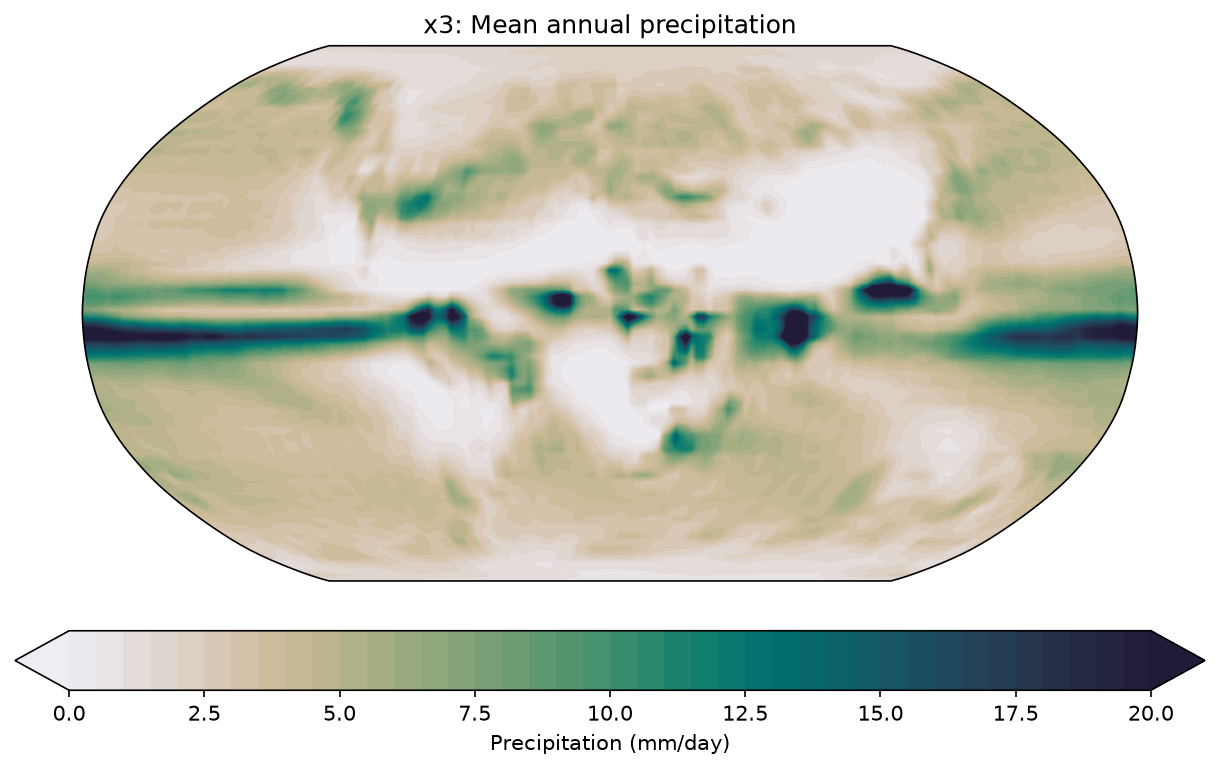

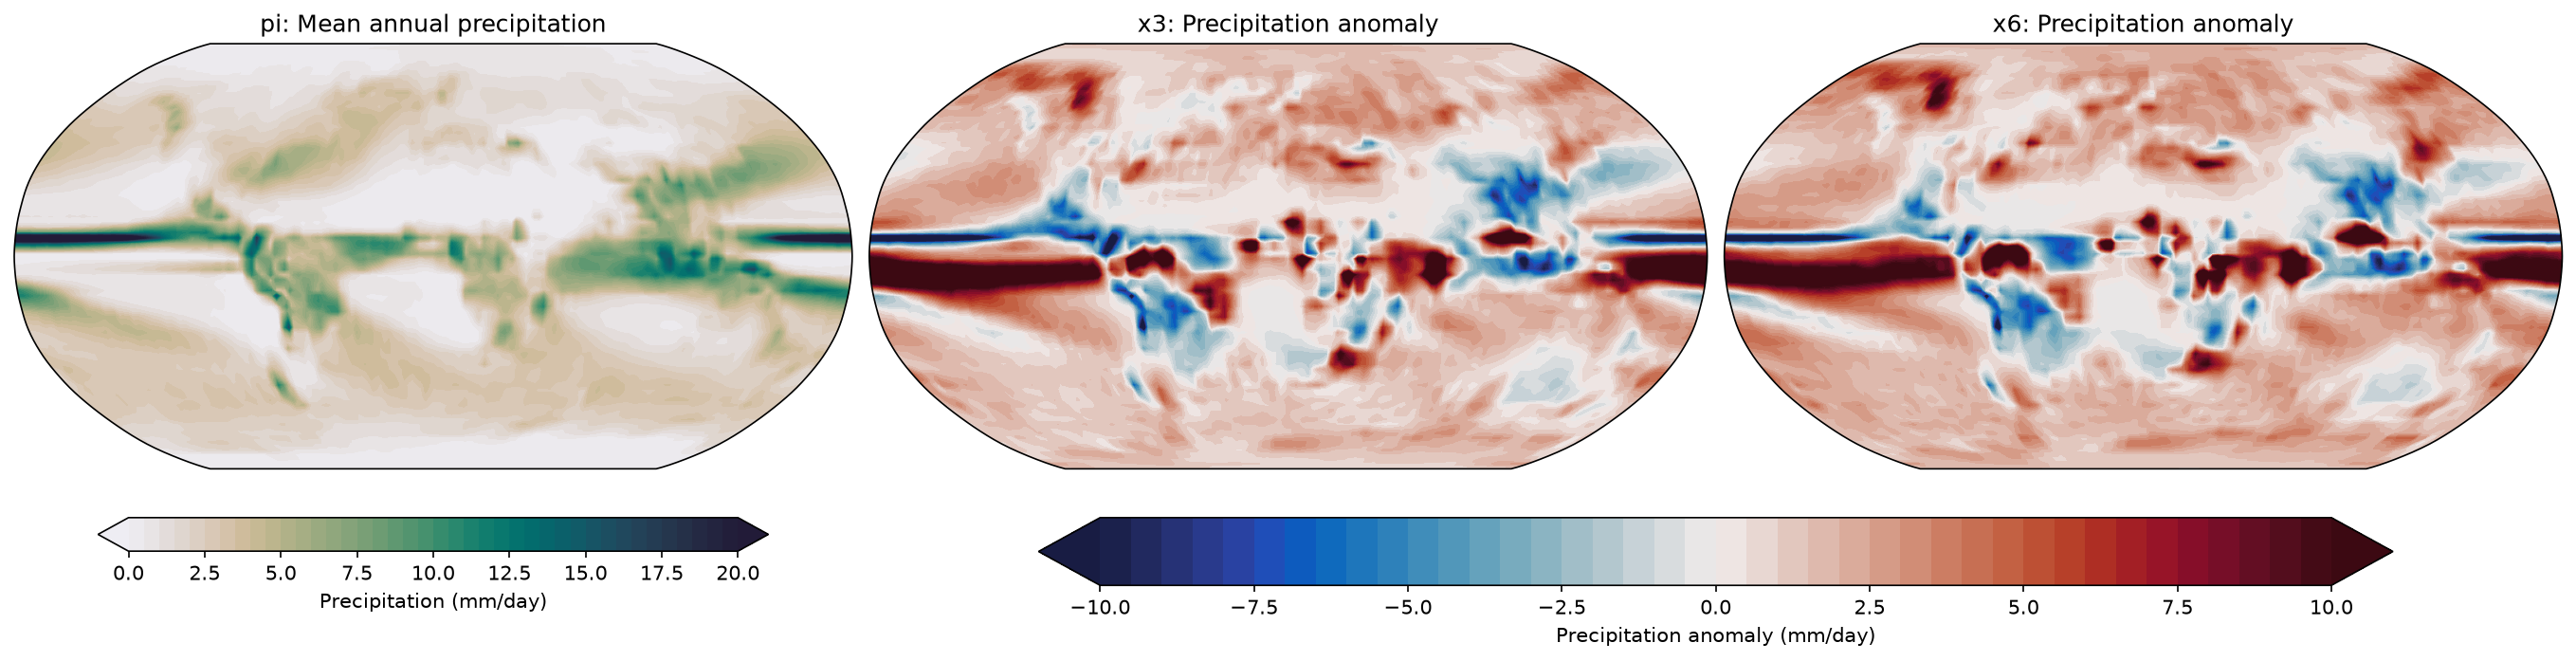

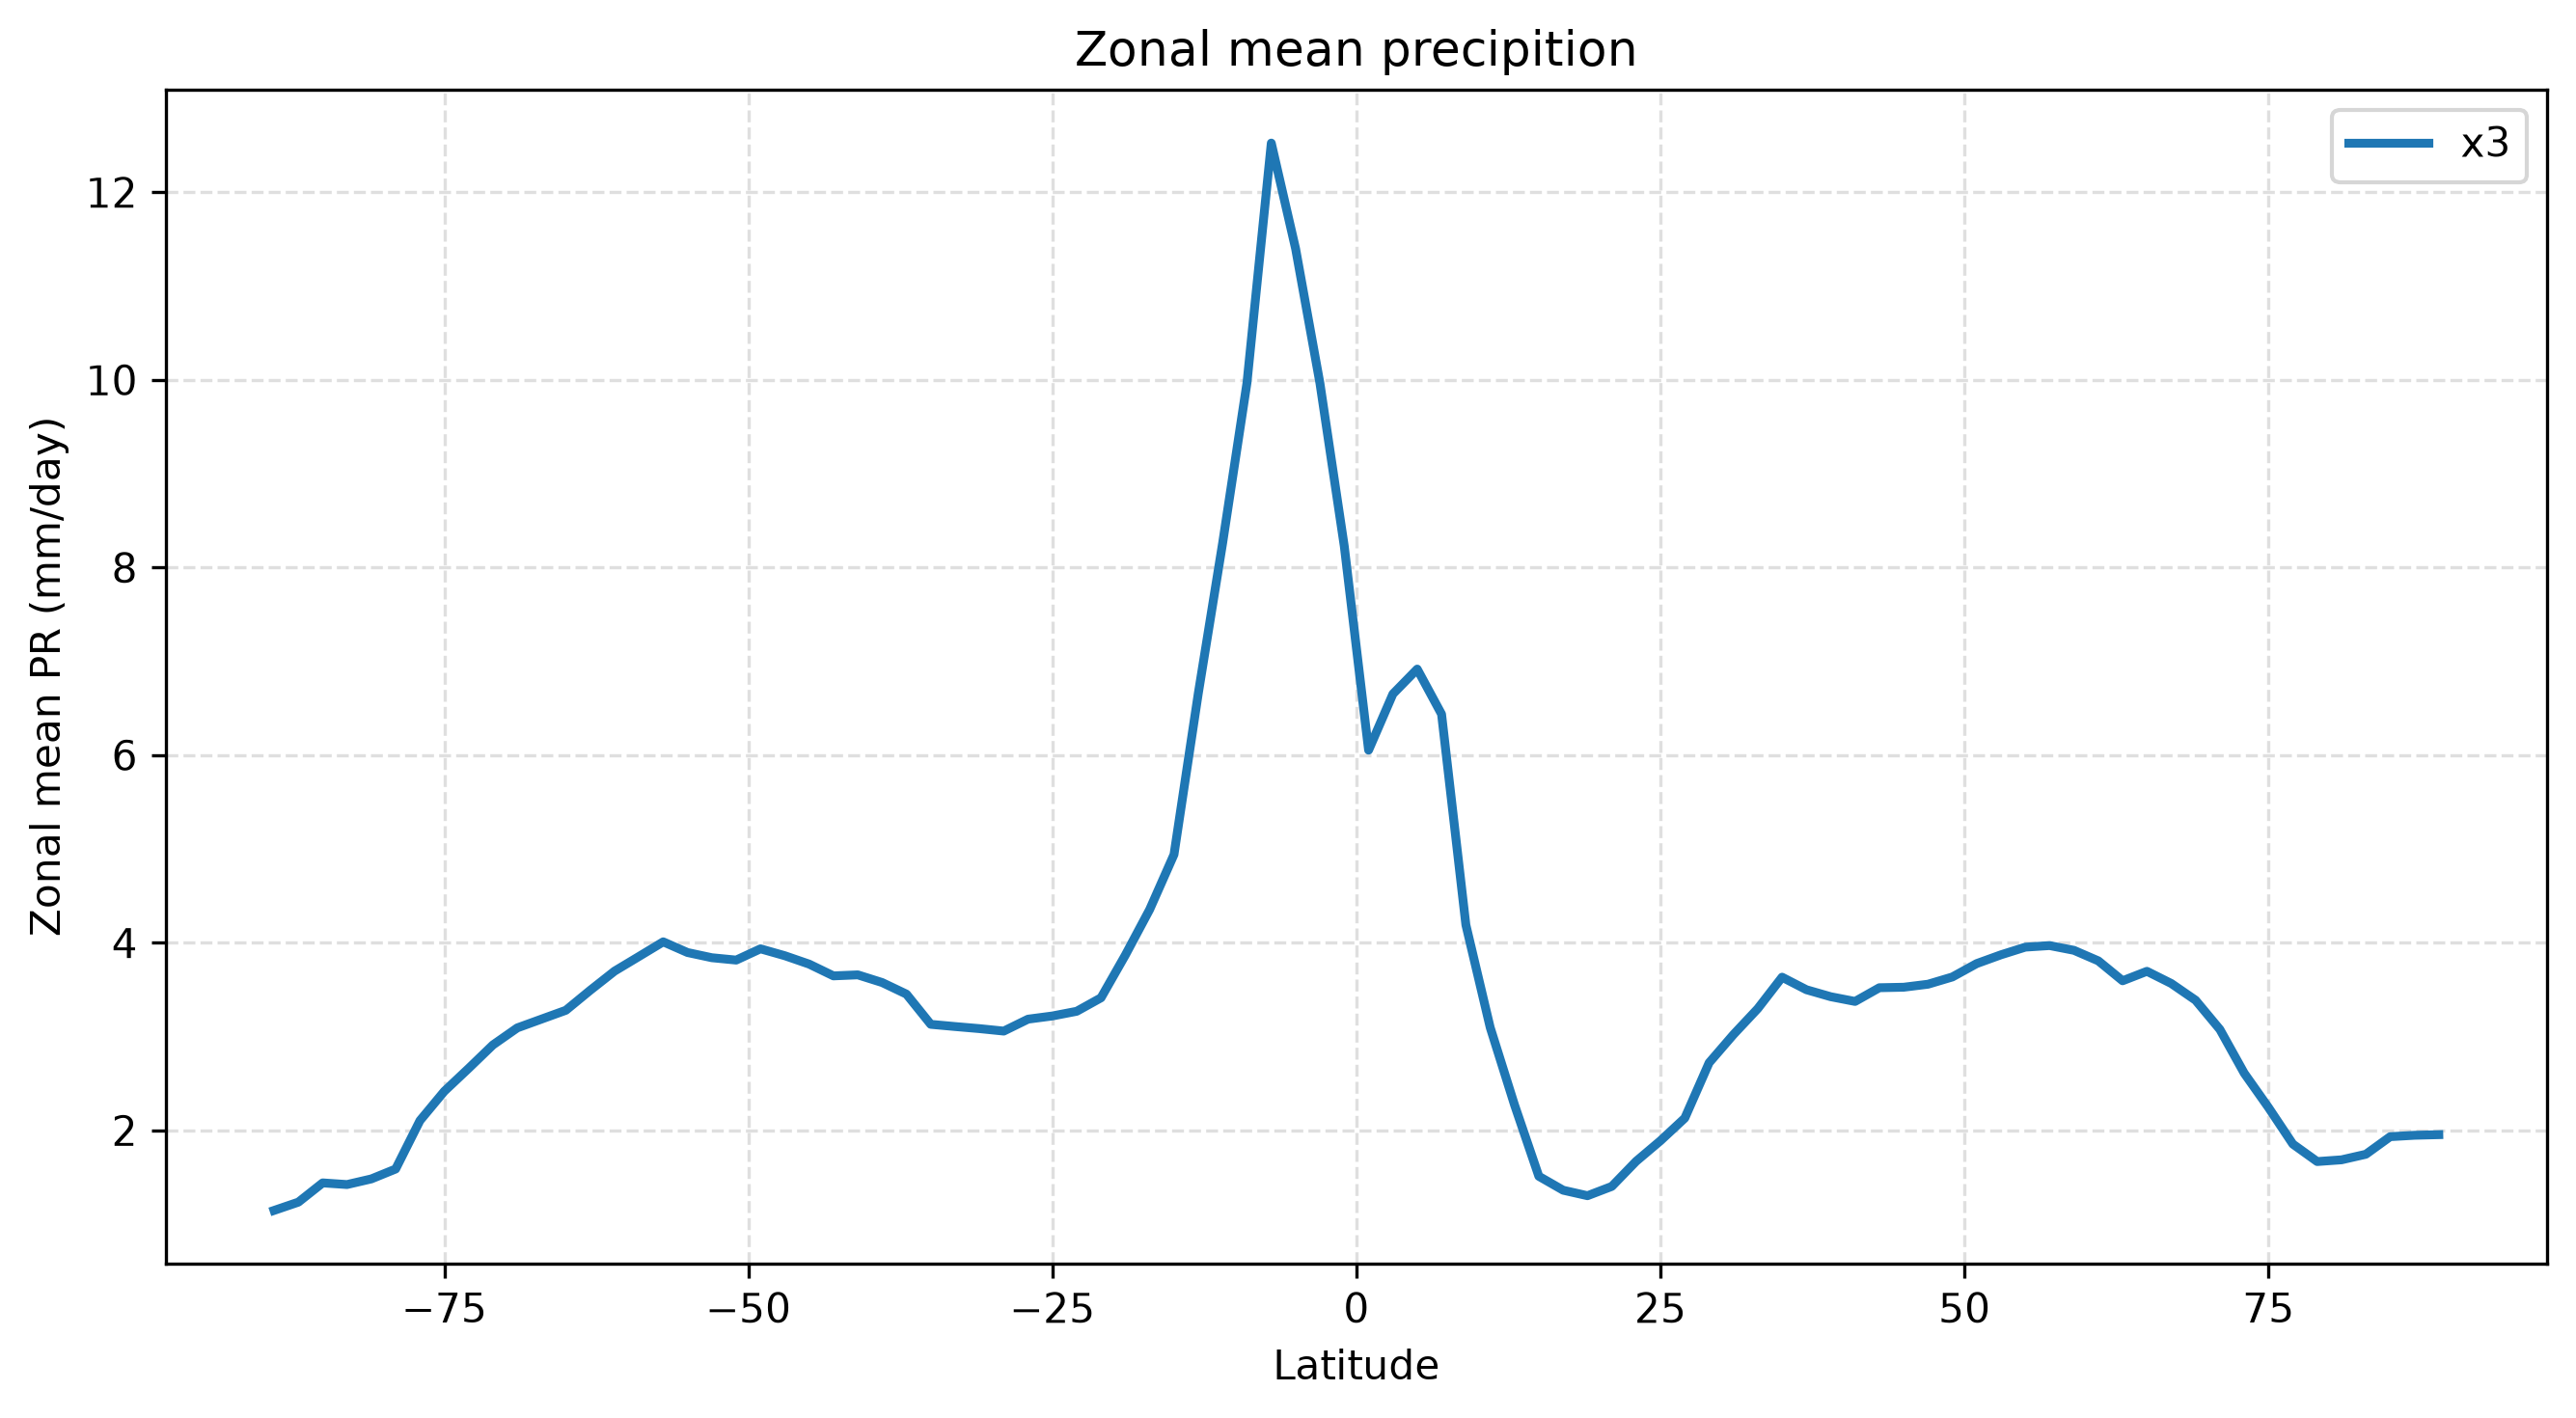

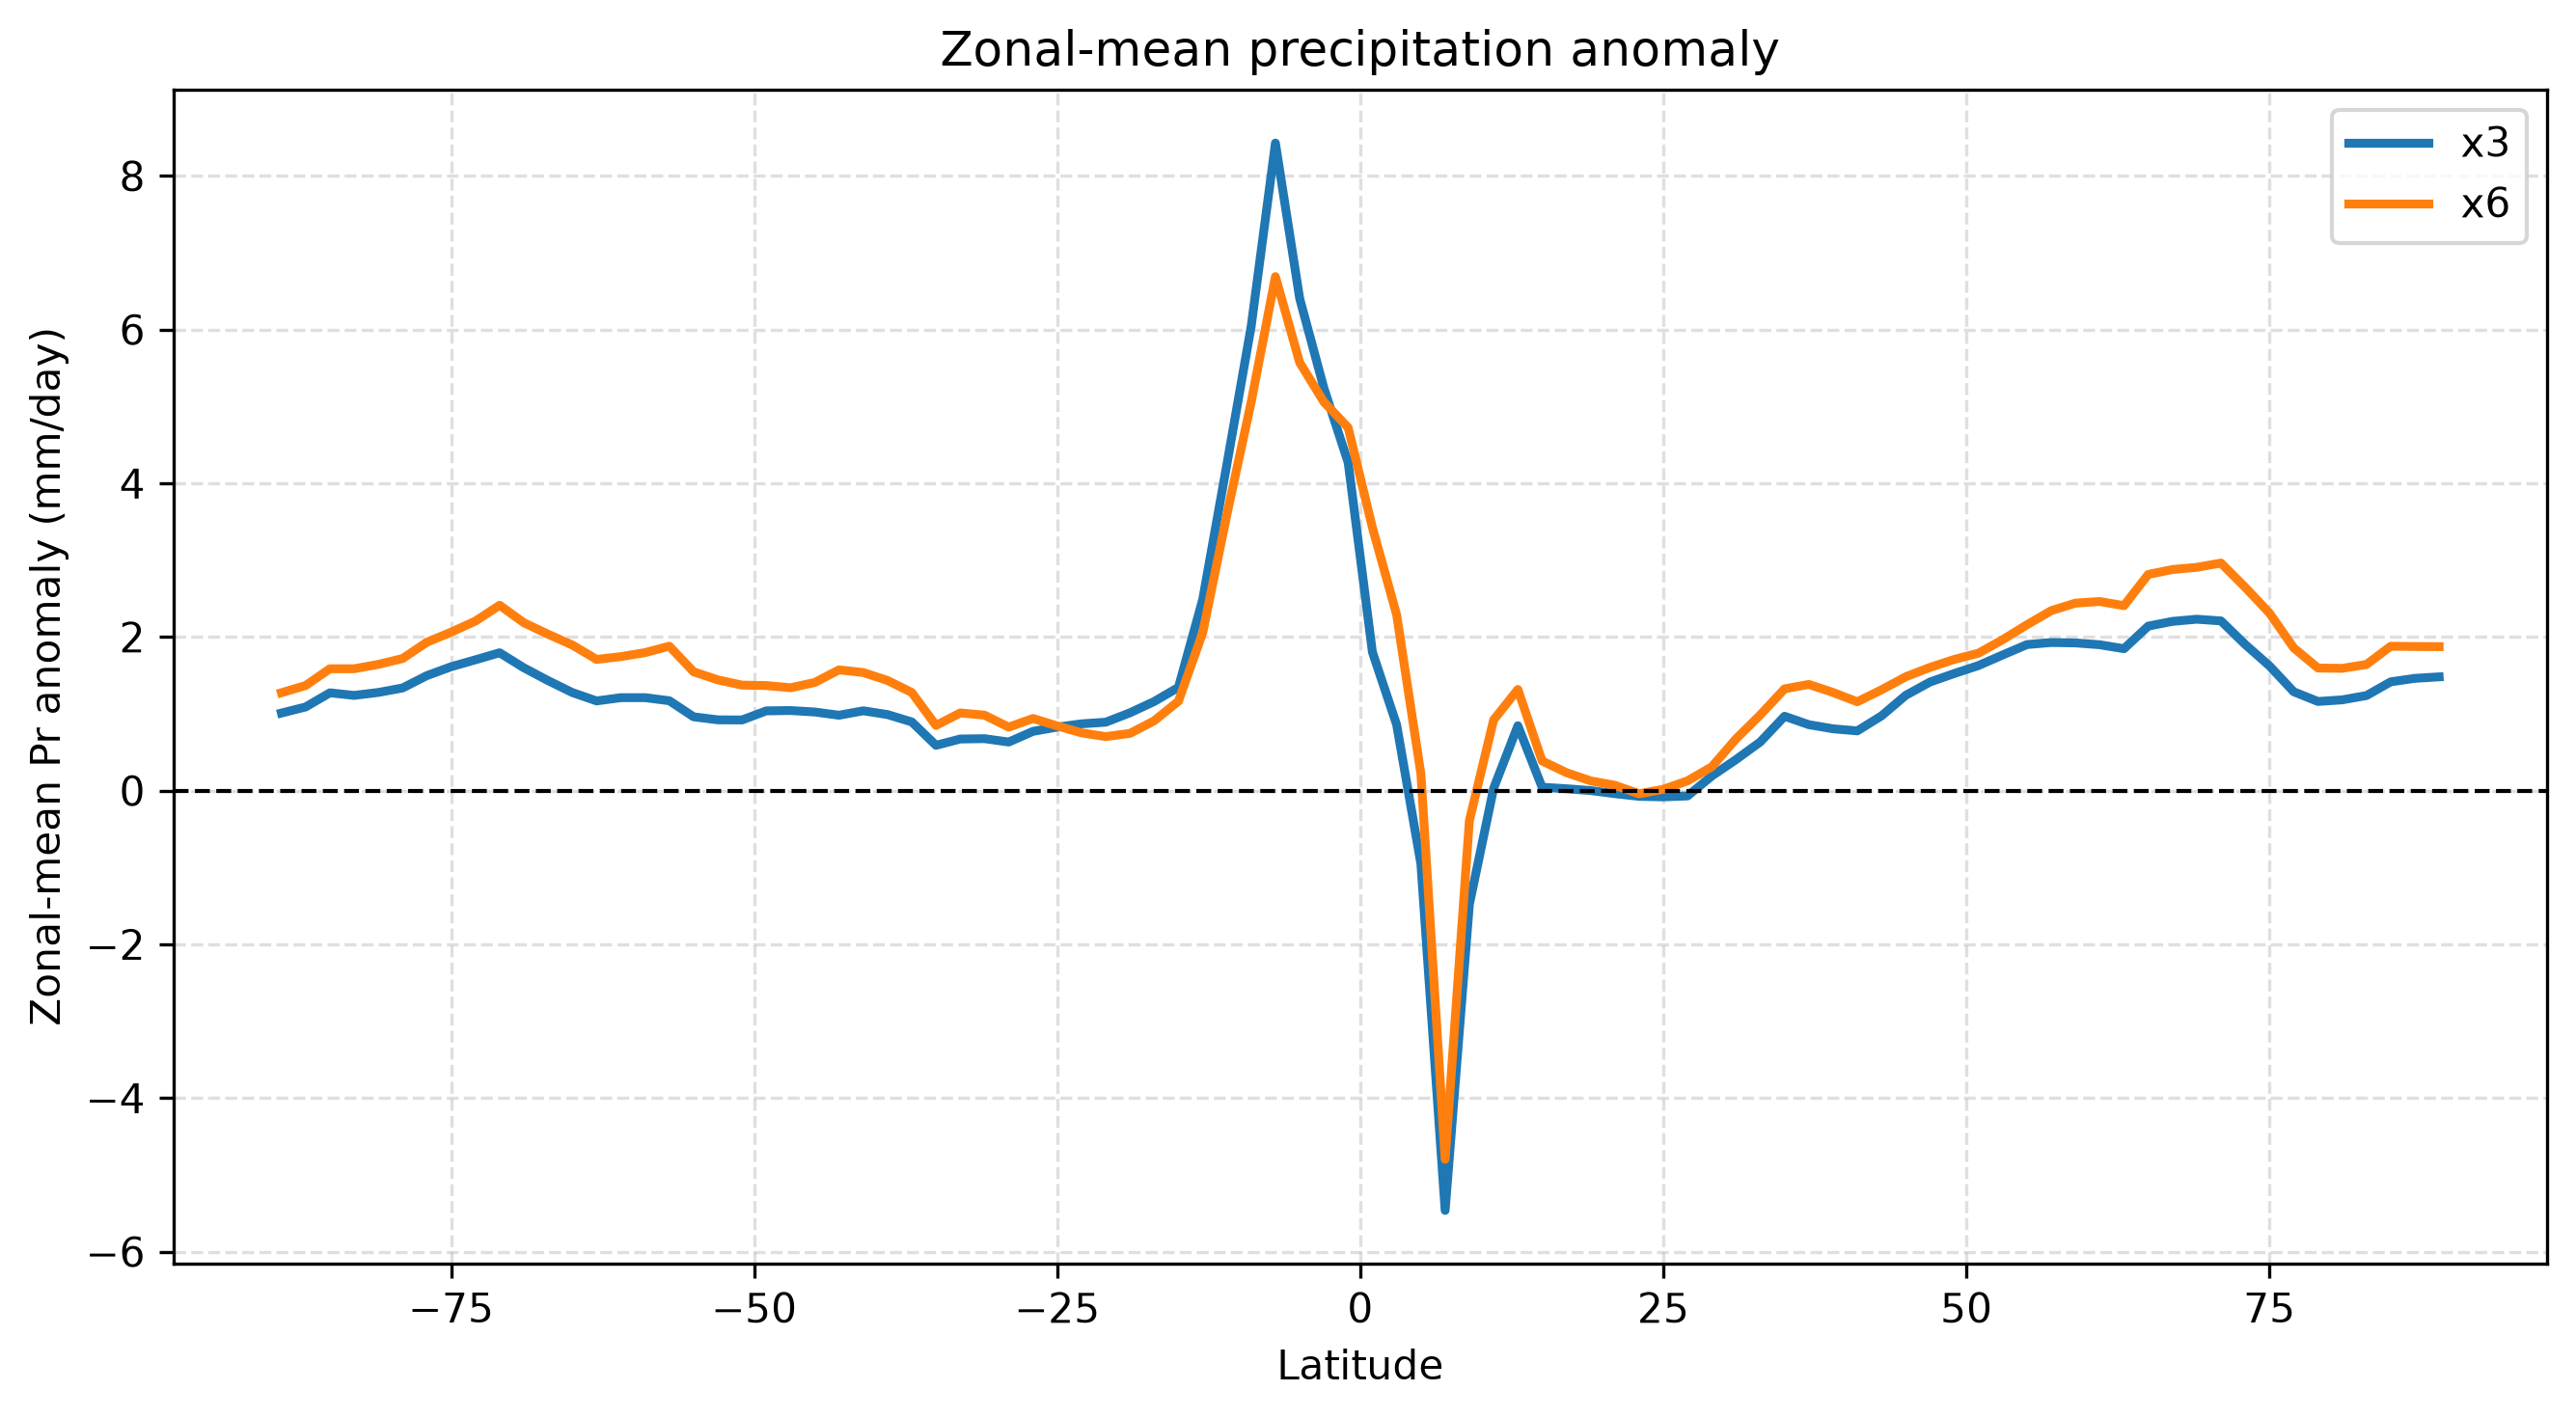

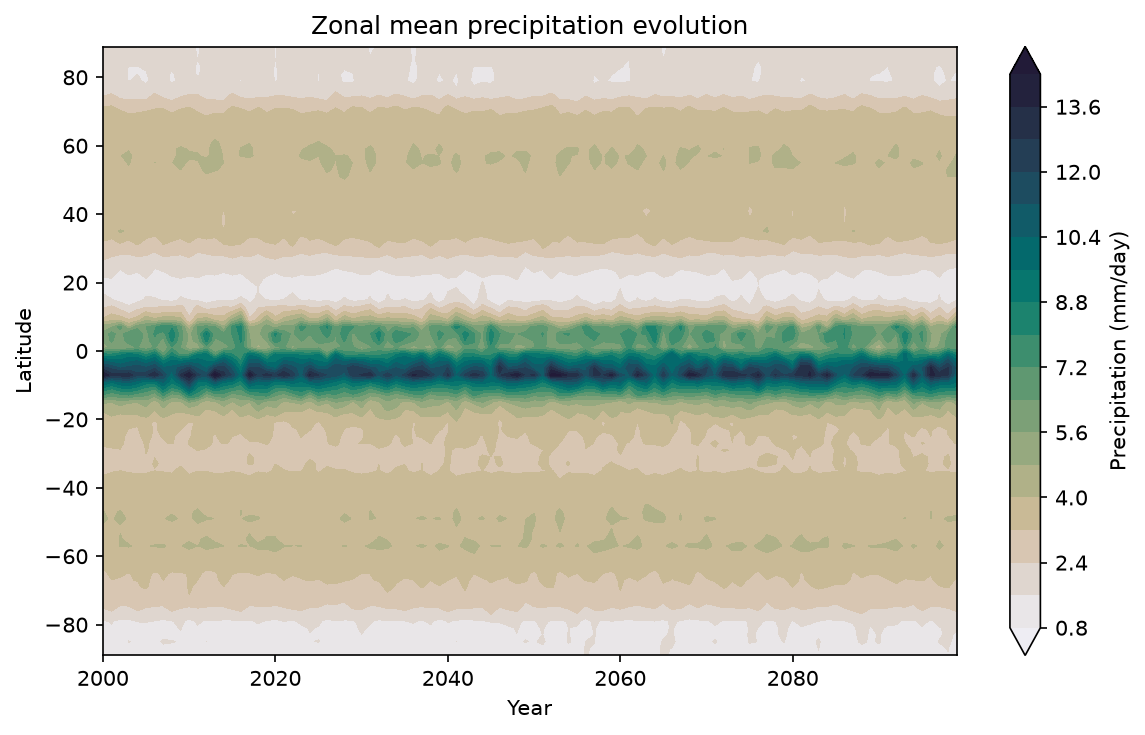

<Figure size 1800x1200 with 0 Axes>

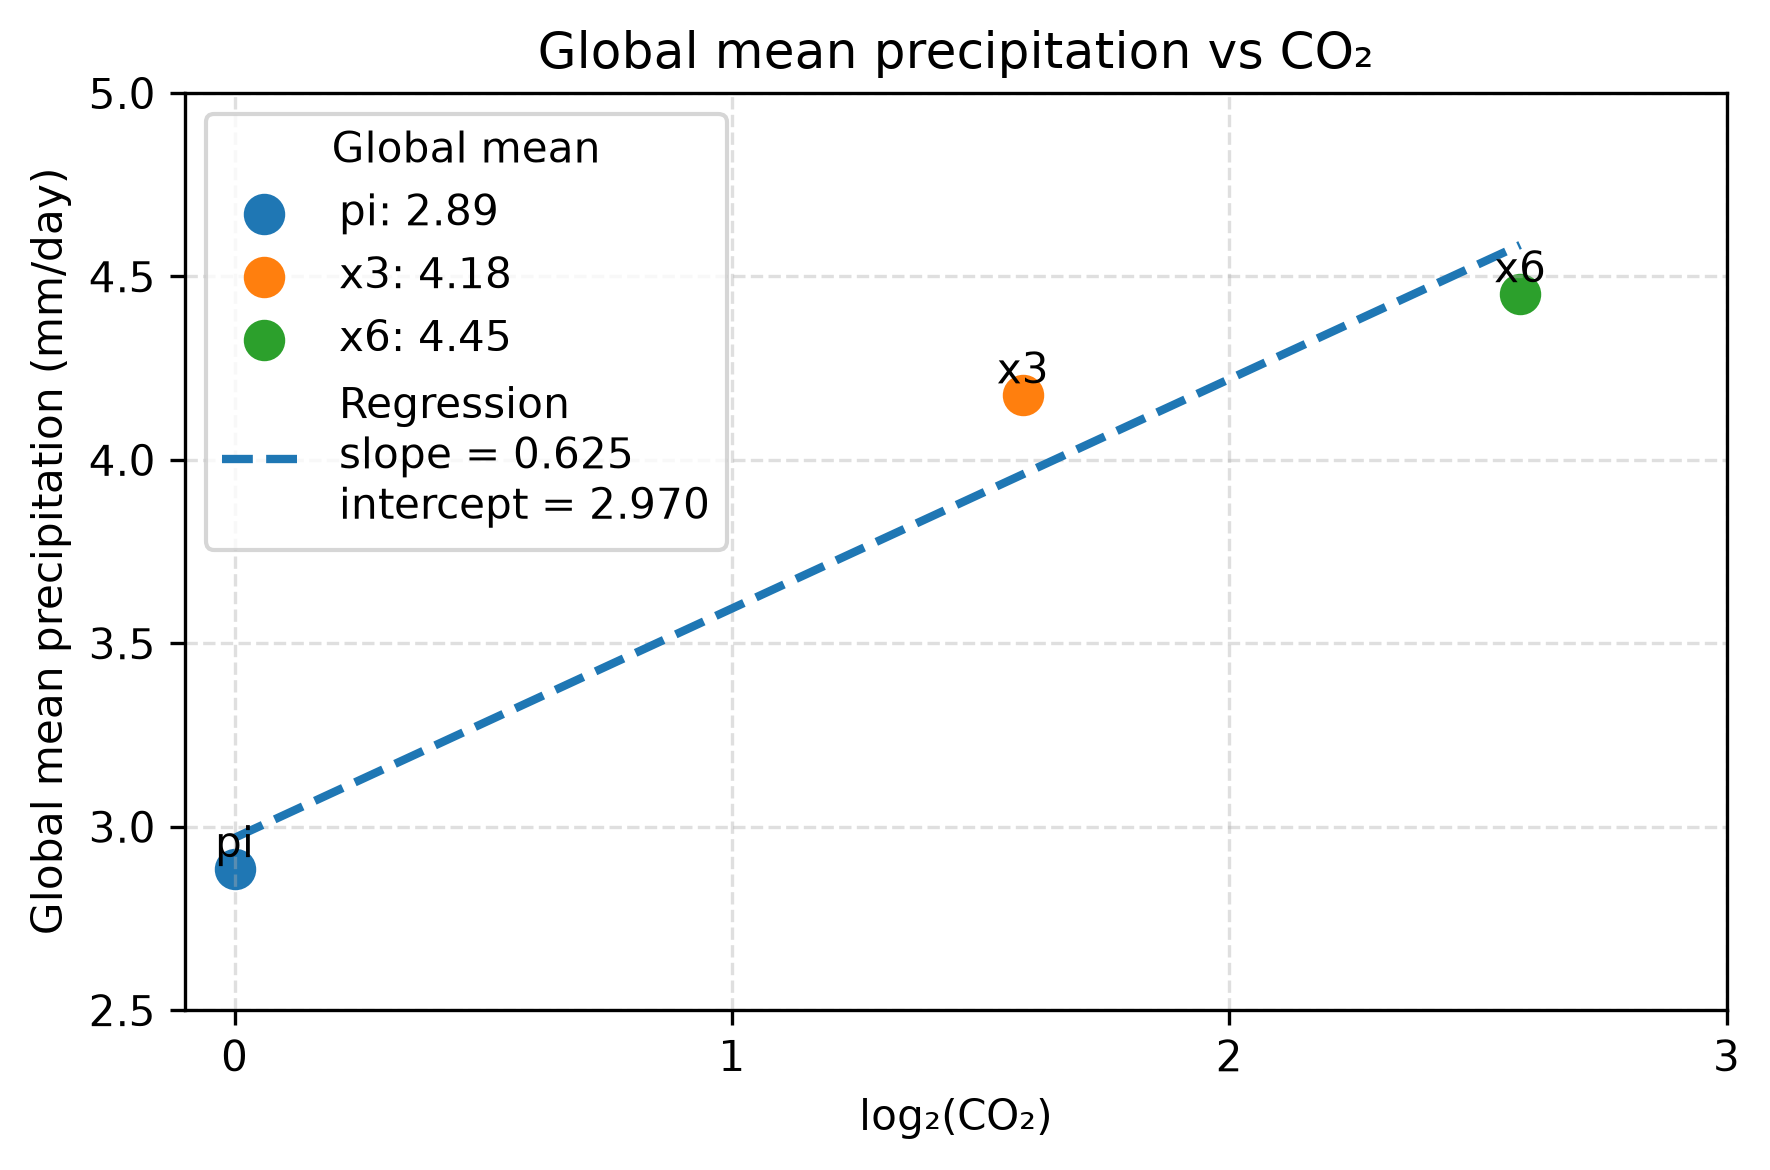

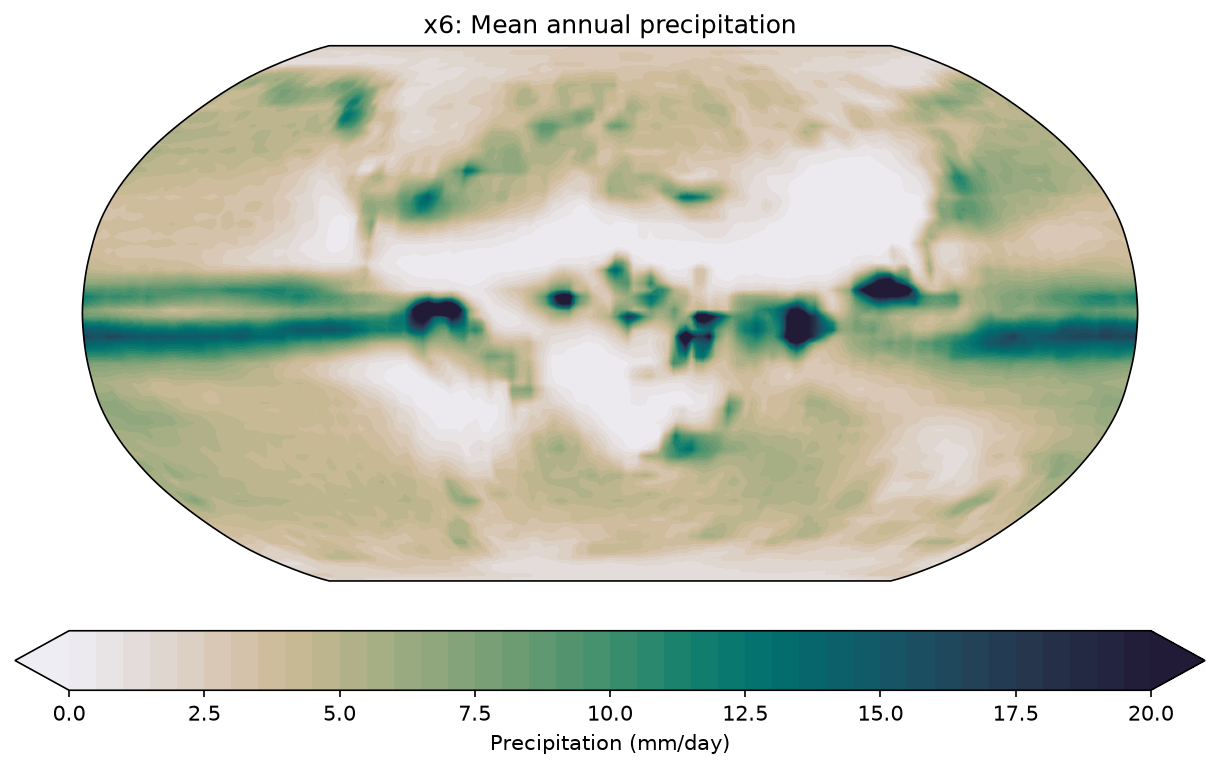

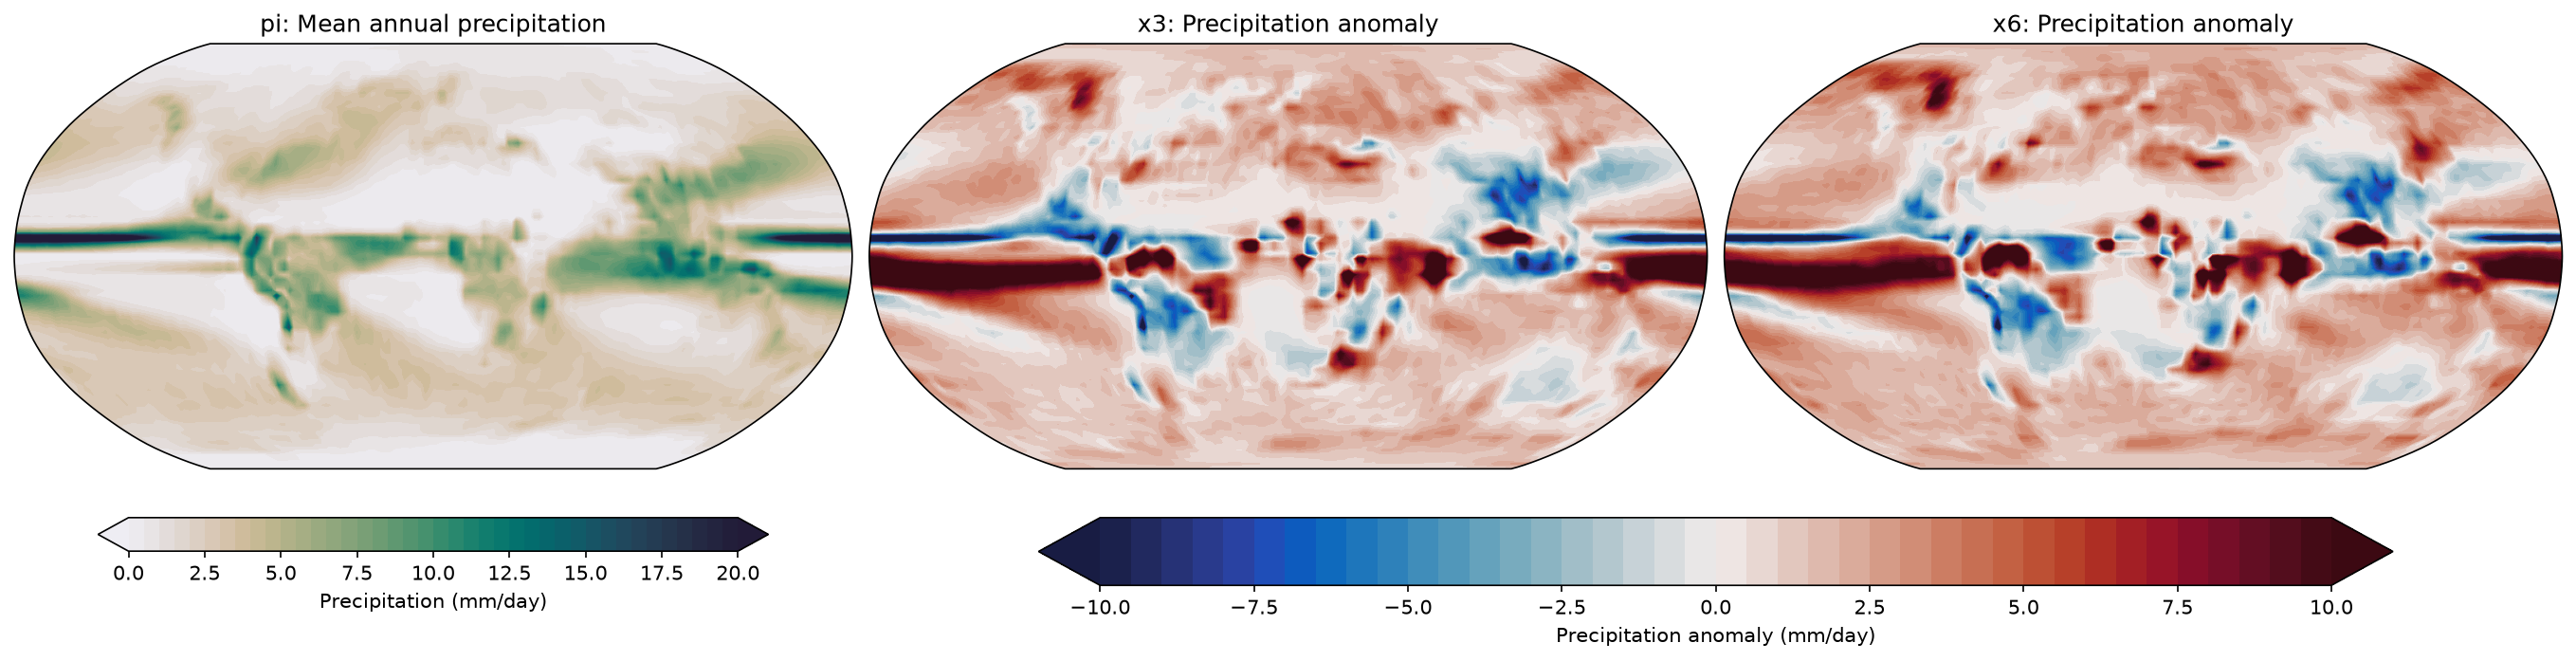

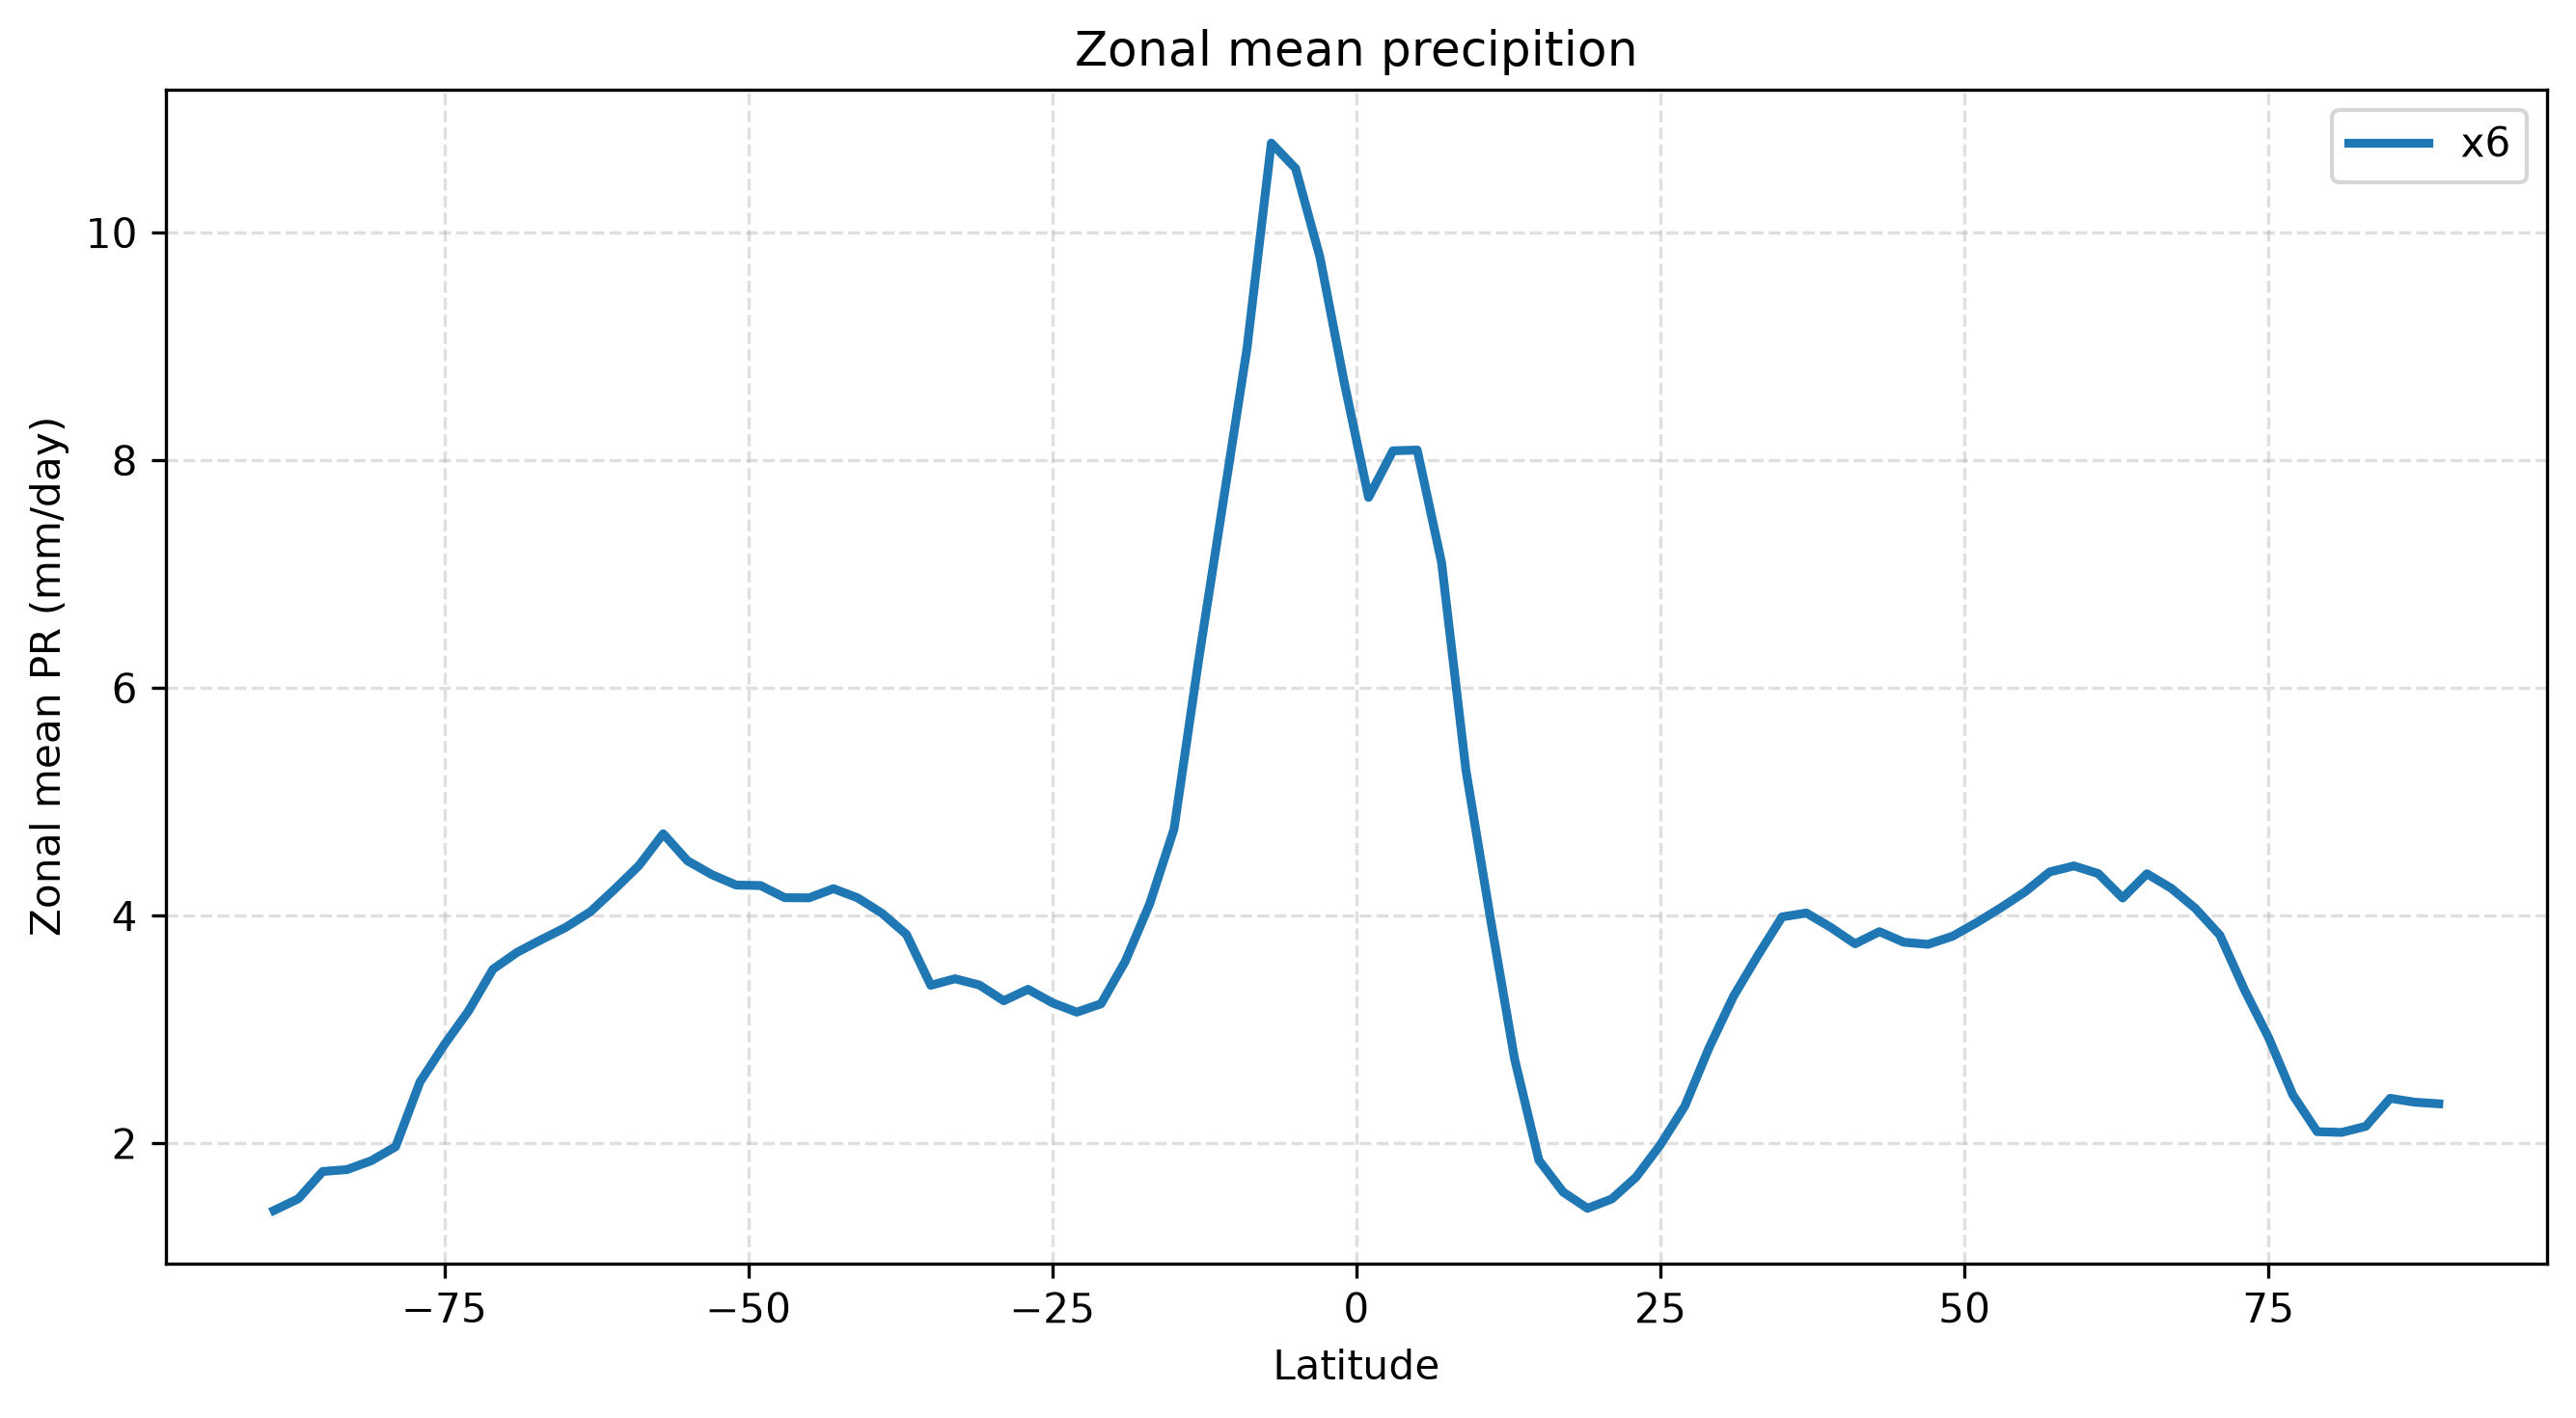

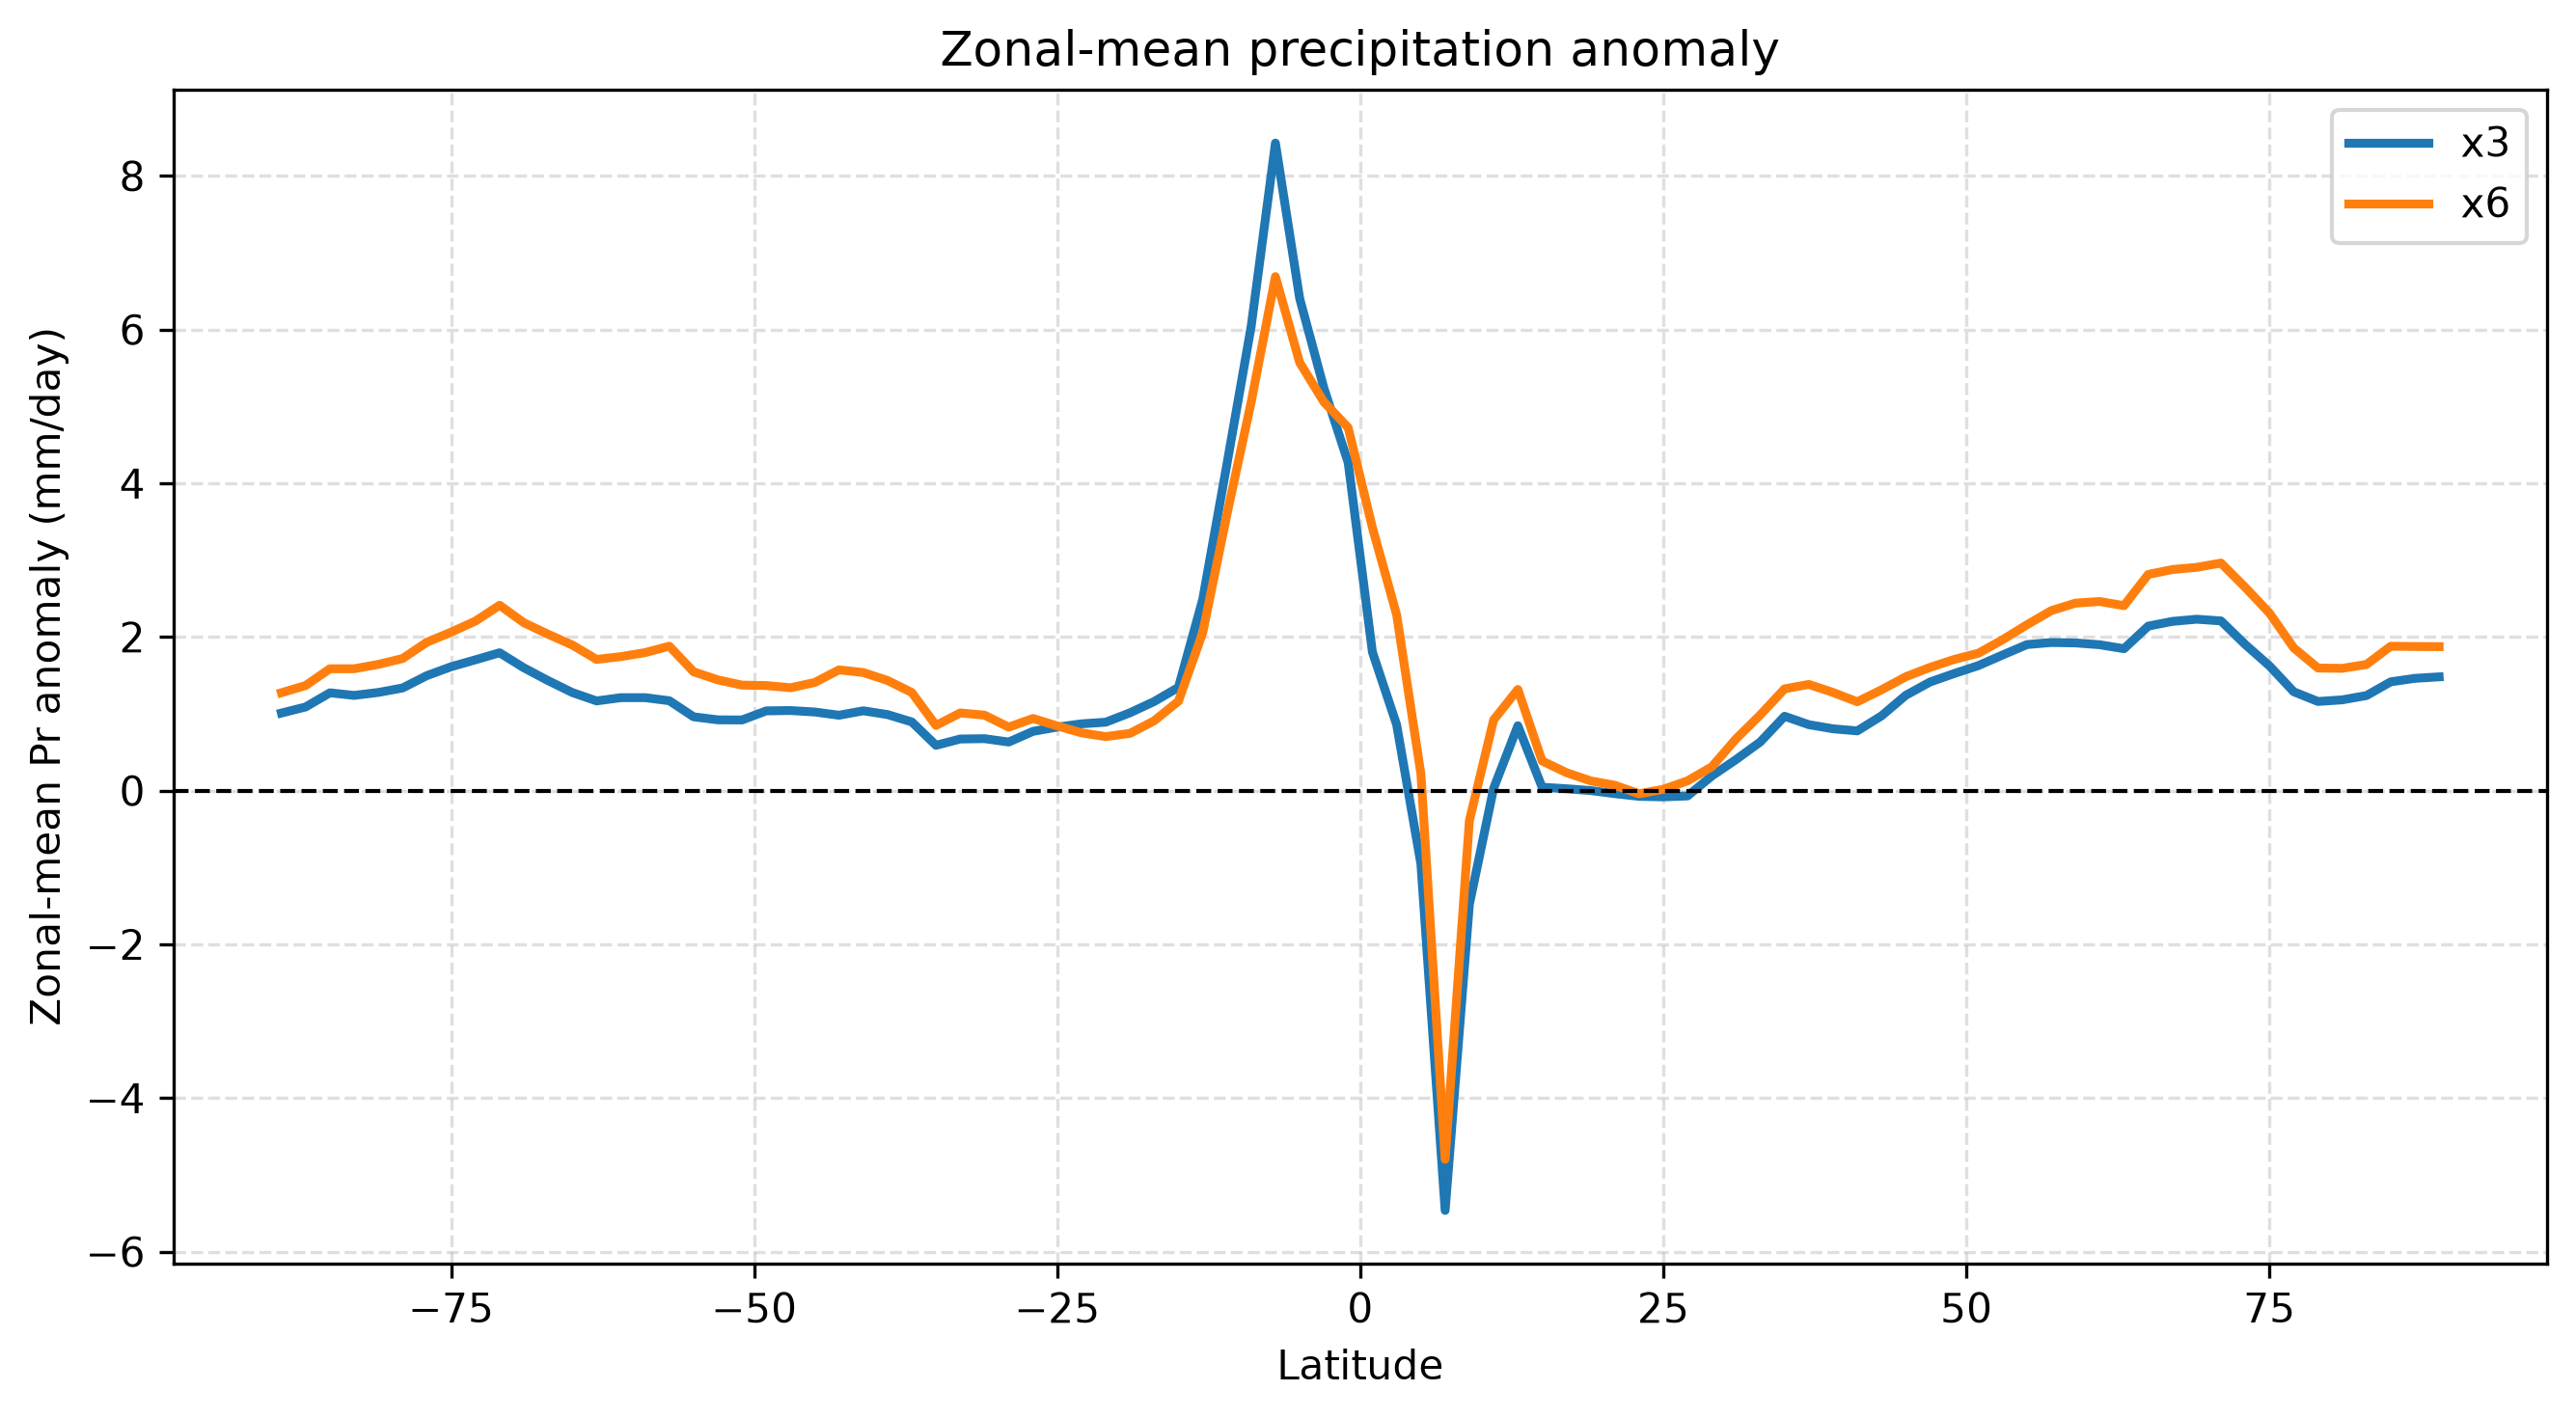

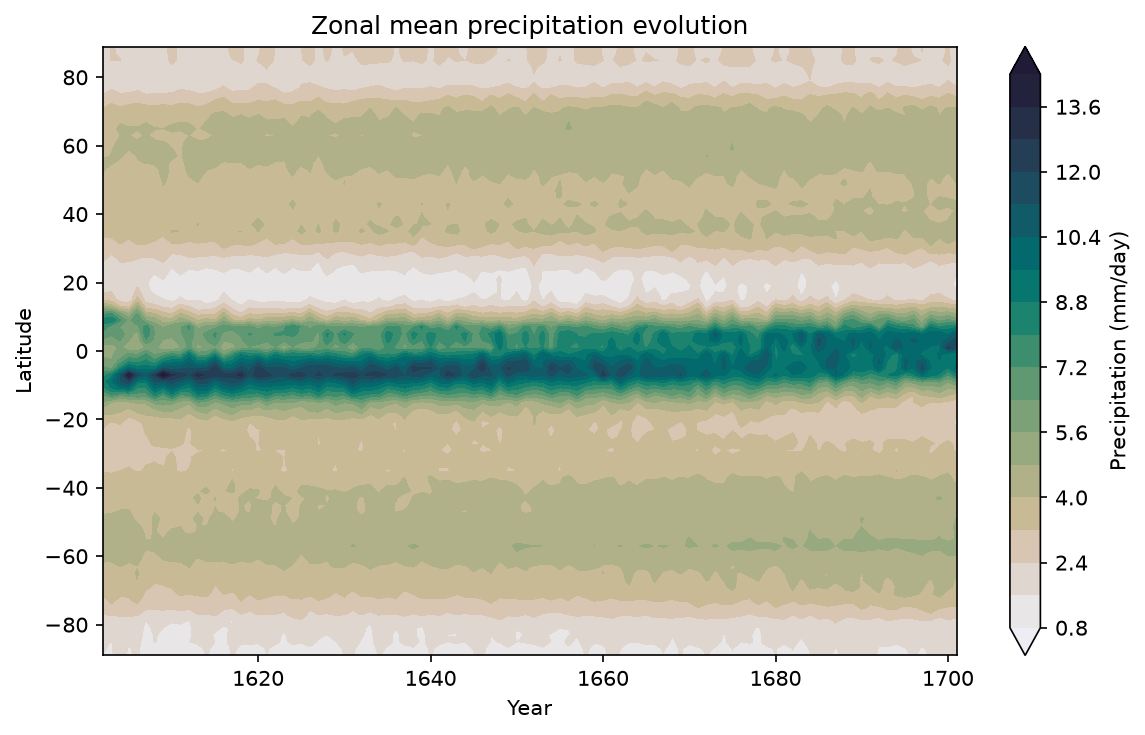

<Figure size 1800x1200 with 0 Axes>

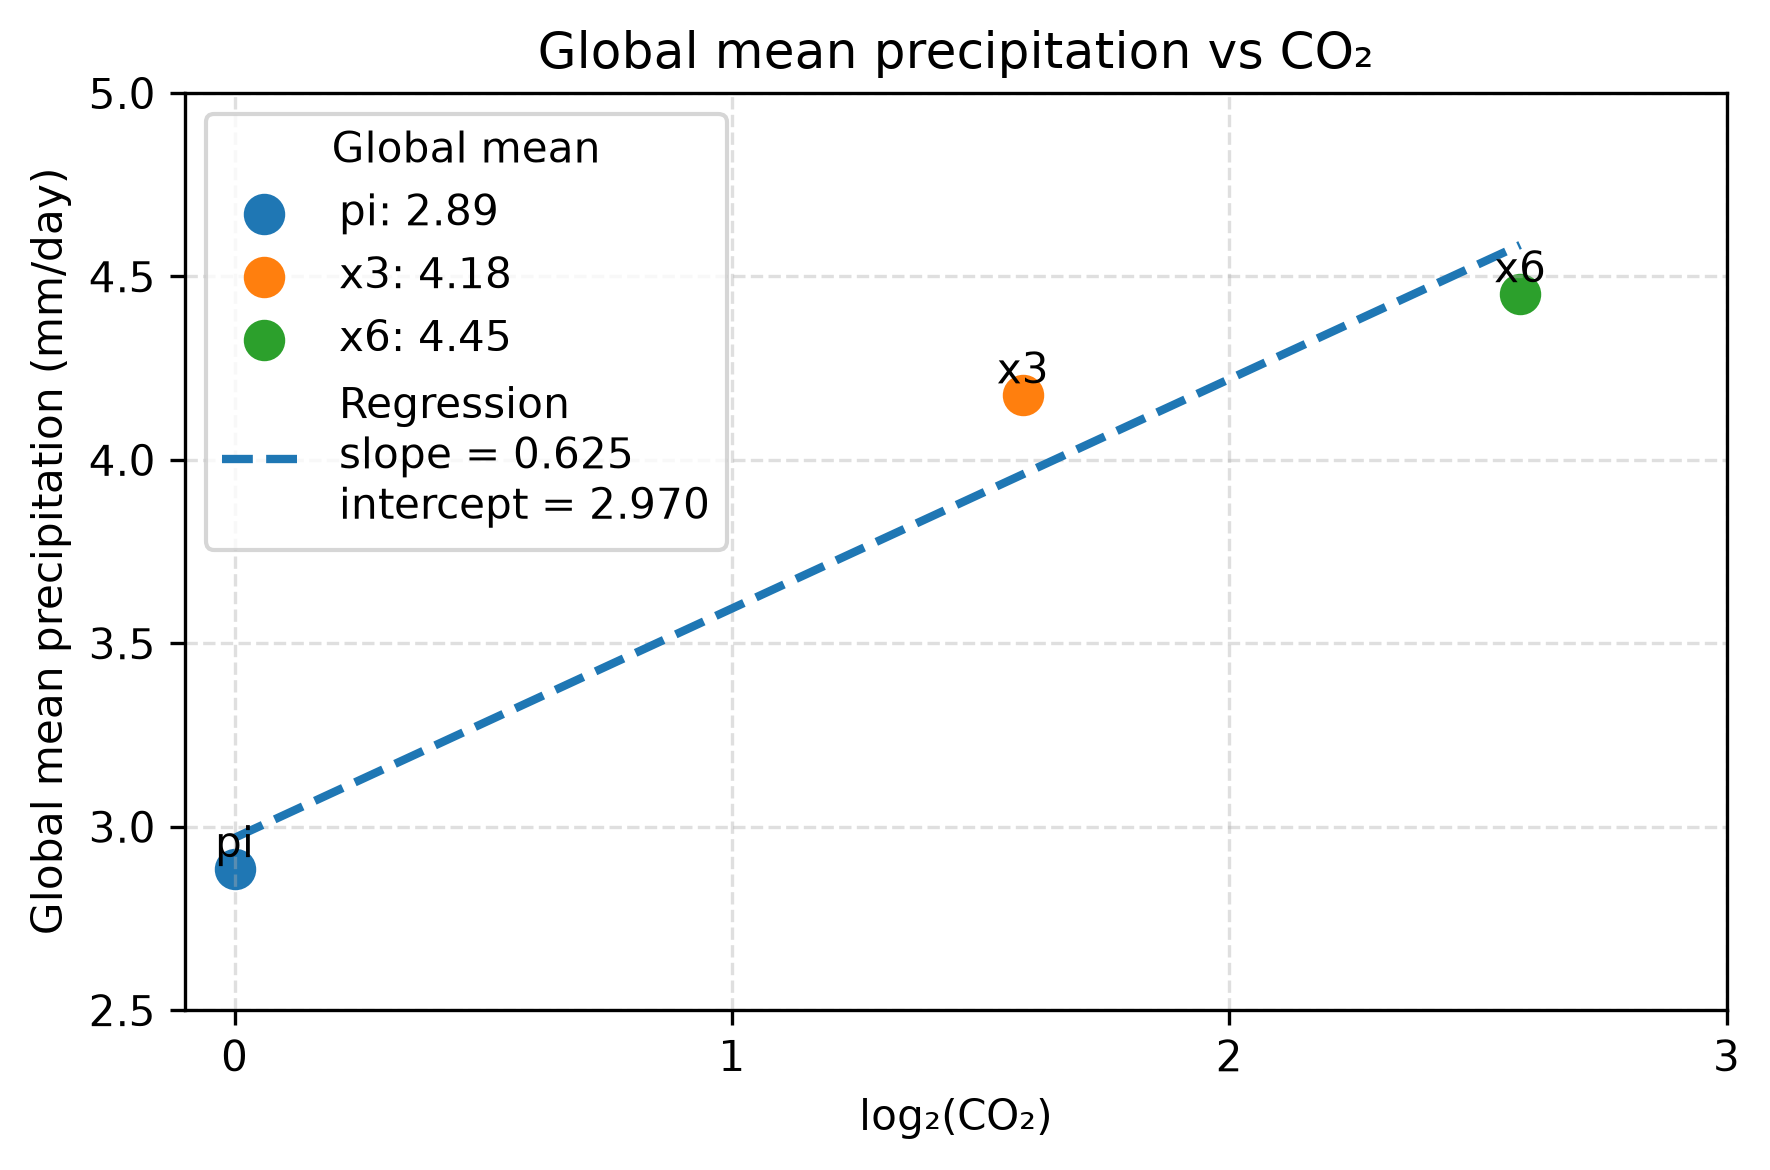

In [ ]:
# ==========================================================
# PR diagnostics
# ==========================================================

diag.pr.run(
    plot=True,
    plot_experiment="x3"
)

# ==========================================================
# PR diagnostics
# ==========================================================

diag.pr.run(
    plot=True,
    plot_experiment="x6"
)

## TOA

In [ ]:
print("Experiments loaded for TOA diagnostics:")
print(list(diag.atm_full.keys()))

for exp, ds in diag.atm_full.items():
    print(
        exp,
        ds.time_counter.dt.year.min().item(),
        ds.time_counter.dt.year.max().item(),
        ds.sizes["time_counter"],
    )

Experiments loaded for TOA diagnostics:
['pi', 'x1.1', 'x1.2', 'x1.3', 'x1.4', 'x1.5']
pi 1600 1799 200
x1.1 1600 1799 200
x1.2 1600 1649 50
x1.3 1600 1650 51
x1.4 1600 1649 50
x1.5 1600 1649 50


In [ ]:
diag.toa.run(plot=False)

print("TAS diagnostics:")
for exp, series in diag.toa.tas.items():
    print(
        exp,
        series.time_counter.dt.year.min().item(),
        series.time_counter.dt.year.max().item(),
        series.sizes["time_counter"]
    )

print("\nTOA diagnostics:")
for exp, series in diag.toa.toa.items():
    print(
        exp,
        series.time_counter.dt.year.min().item(),
        series.time_counter.dt.year.max().item(),
        series.sizes["time_counter"]
    )

TAS diagnostics:
pi 1600 1799 200
x1.1 1600 1799 200
x1.2 1600 1649 50
x1.3 1600 1650 51
x1.4 1600 1649 50
x1.5 1600 1649 50

TOA diagnostics:
pi 1600 1799 200
x1.1 1600 1799 200
x1.2 1600 1649 50
x1.3 1600 1650 51
x1.4 1600 1649 50
x1.5 1600 1649 50


In [ ]:
import numpy as np
for exp in diag.toa.tas:

    tas = diag.toa.tas[exp].isel(time_counter=slice(0, 50))
    toa = diag.toa.toa[exp].isel(time_counter=slice(0, 50))

    x = tas.values
    y = toa.values

    valid = np.isfinite(x) & np.isfinite(y)

    print(f"\n{exp}")
    print(
        "Years:",
        tas.time_counter.dt.year.min().item(),
        "-",
        tas.time_counter.dt.year.max().item(),
    )
    print("Selected points:", len(x))
    print("Valid pairs:", valid.sum())
    print("Invalid pairs:", (~valid).sum())

    print("TAS range:", np.nanmin(x), "to", np.nanmax(x))
    print("TOA range:", np.nanmin(y), "to", np.nanmax(y))


pi
Years: 1600 - 1649
Selected points: 50
Valid pairs: 50
Invalid pairs: 0
TAS range: 12.548632690816548 to 13.52481860750772
TOA range: -0.2432715945456158 to 1.3367280930410153

x1.1
Years: 1600 - 1649
Selected points: 50
Valid pairs: 50
Invalid pairs: 0
TAS range: 12.47203166340804 to 13.261079831076252
TOA range: -0.2614168970554615 to 1.7749056371873178

x1.2
Years: 1600 - 1649
Selected points: 50
Valid pairs: 50
Invalid pairs: 0
TAS range: 13.427113681060233 to 14.046044559368731
TOA range: -0.3087894815037943 to 1.1425241717007464

x1.3
Years: 1600 - 1649
Selected points: 50
Valid pairs: 50
Invalid pairs: 0
TAS range: 12.548632690816548 to 13.52481860750772
TOA range: -0.2432715945456158 to 1.3367280930410153

x1.4
Years: 1600 - 1649
Selected points: 50
Valid pairs: 50
Invalid pairs: 0
TAS range: 13.427113681060233 to 14.046044559368731
TOA range: -0.3087894815037943 to 1.1425241717007464

x1.5
Years: 1600 - 1649
Selected points: 50
Valid pairs: 50
Invalid pairs: 0
TAS range: 1

x3: 50 valid points
x3.1: 50 valid points
x3.2: 49 valid points
x4: 49 valid points
x6: 50 valid points


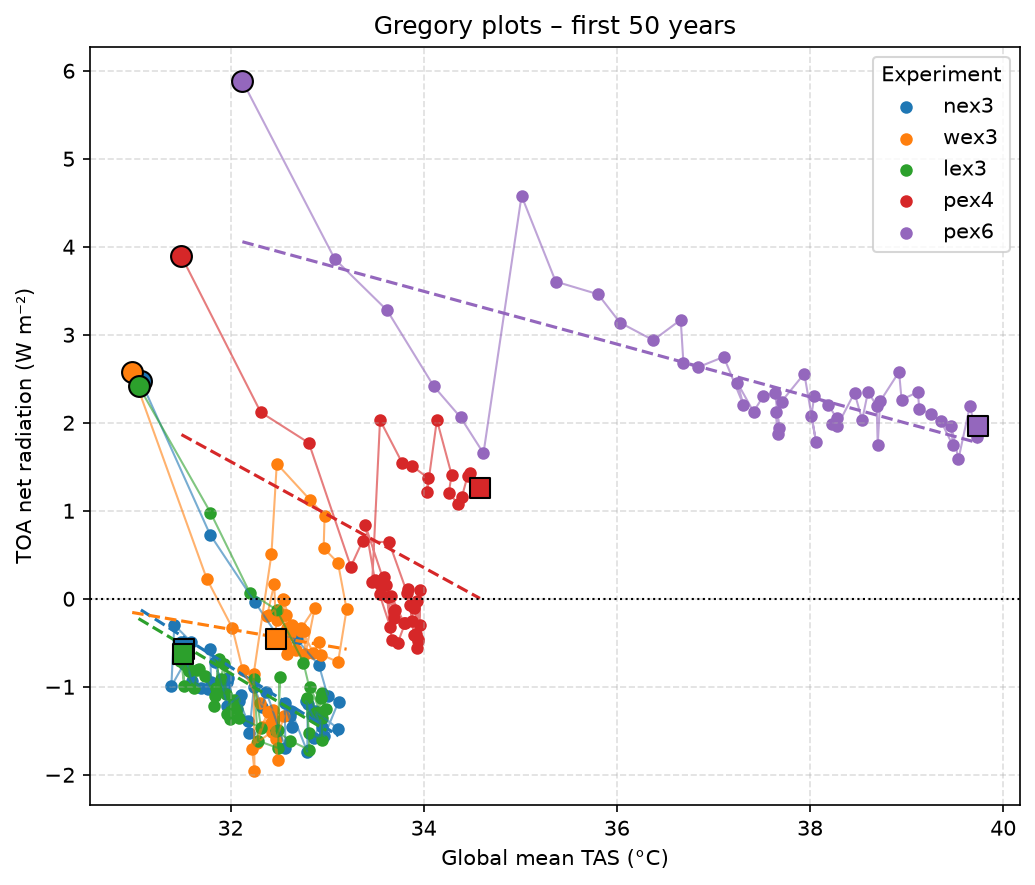

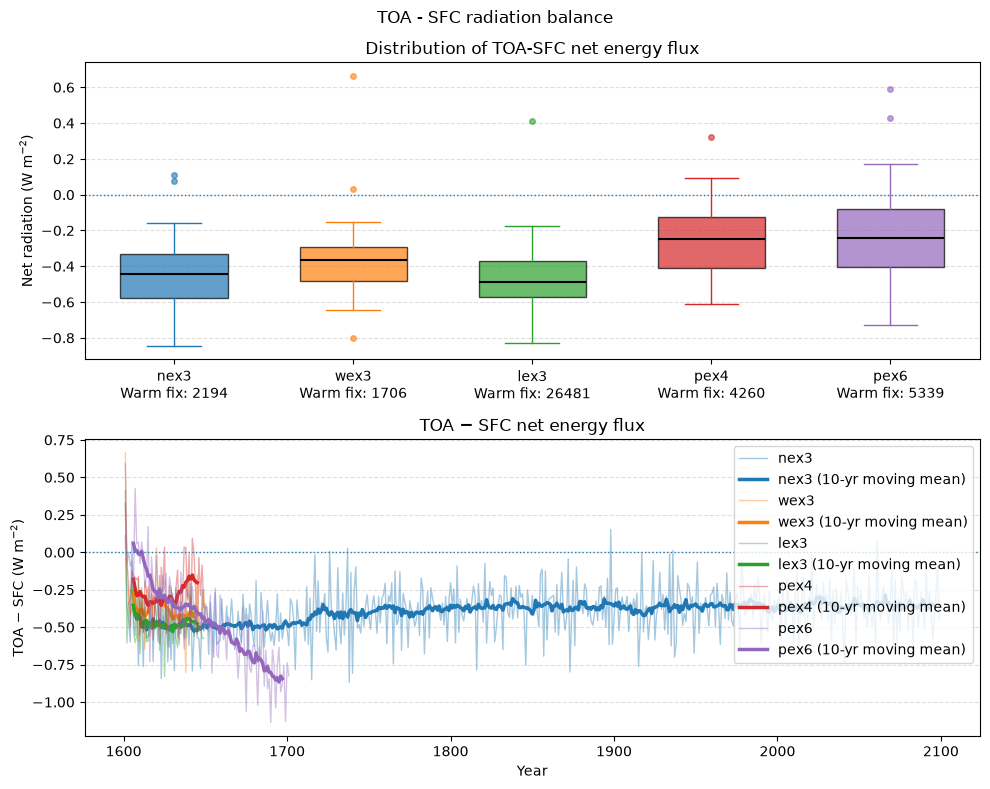

In [3]:
# ==========================================================
# TOA diagnostics
# ==========================================================

diag.toa.run(
    f_years=50,
    moving_mean=10,
    plot=True,
    save=False,
)

## SSTs

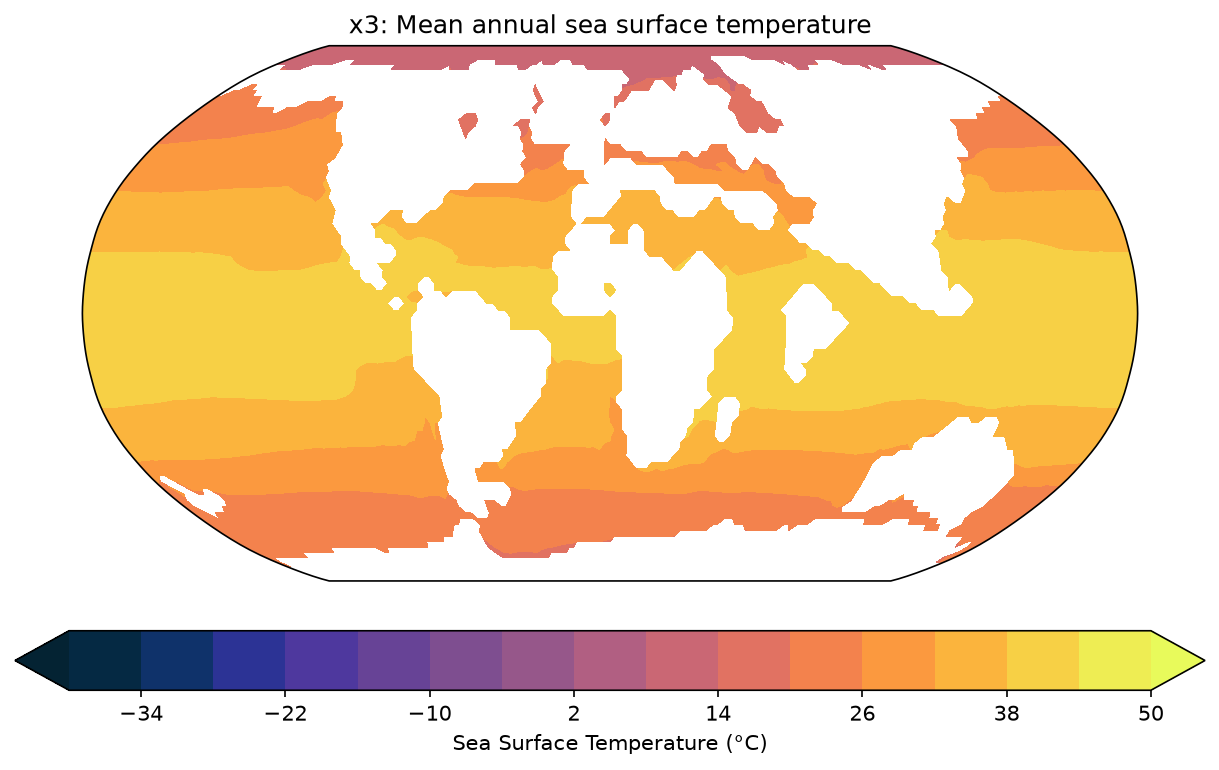

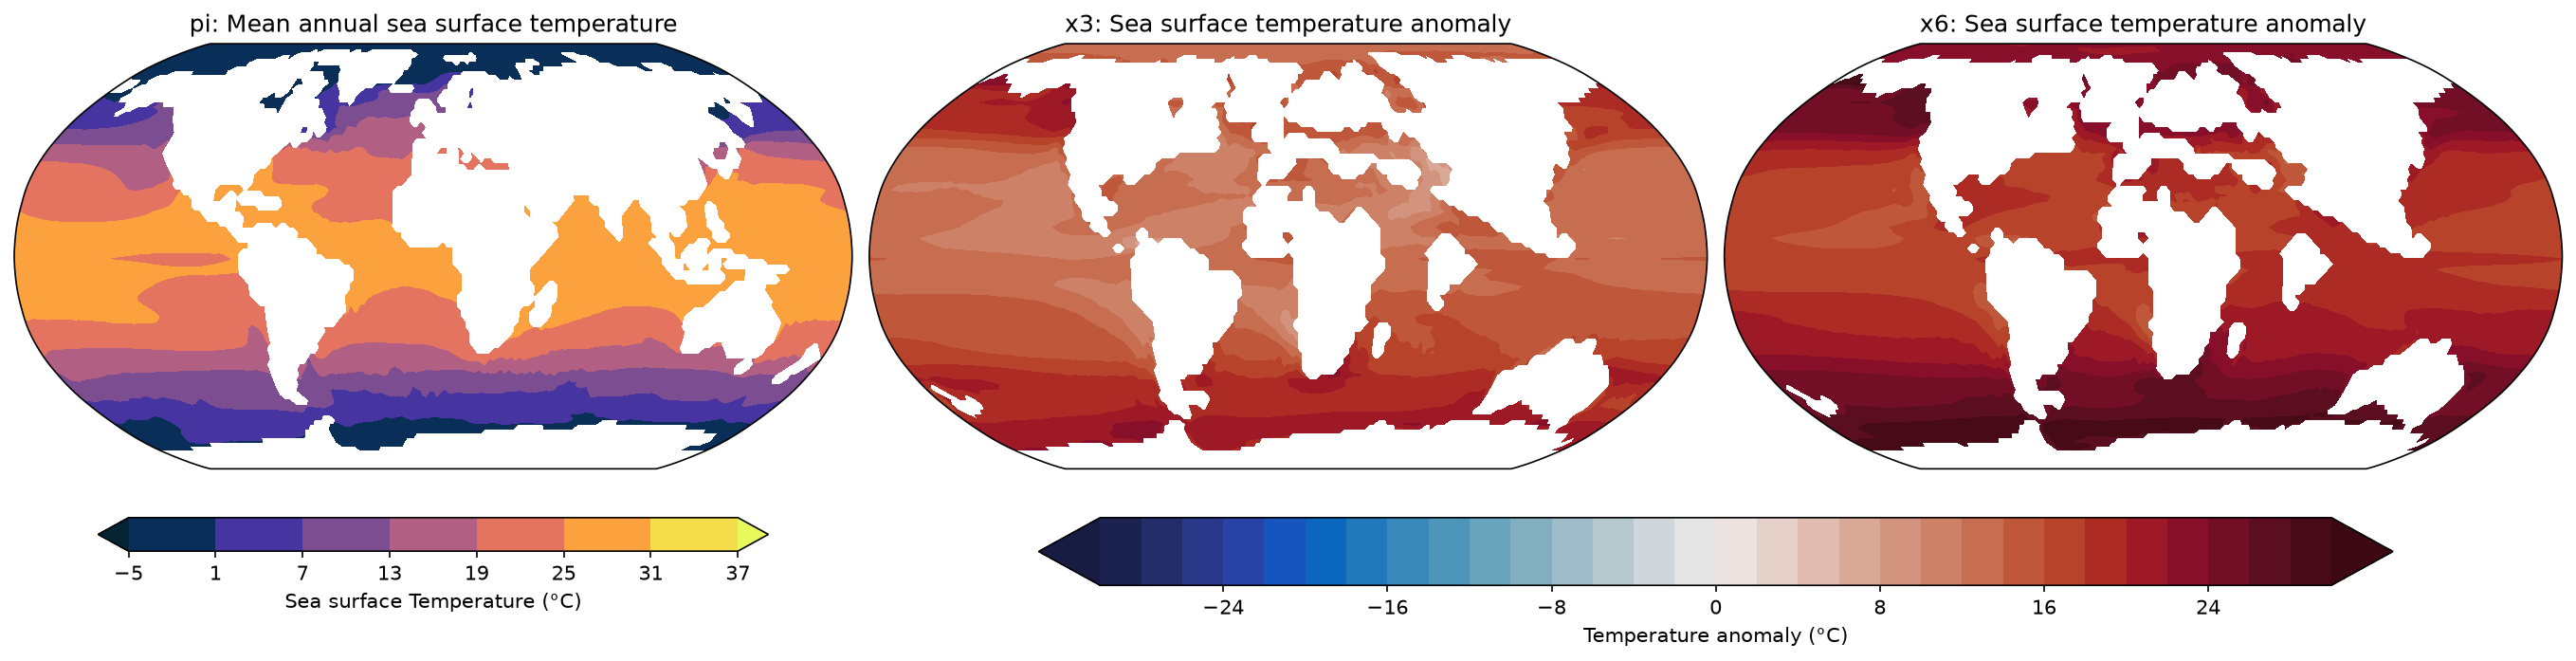

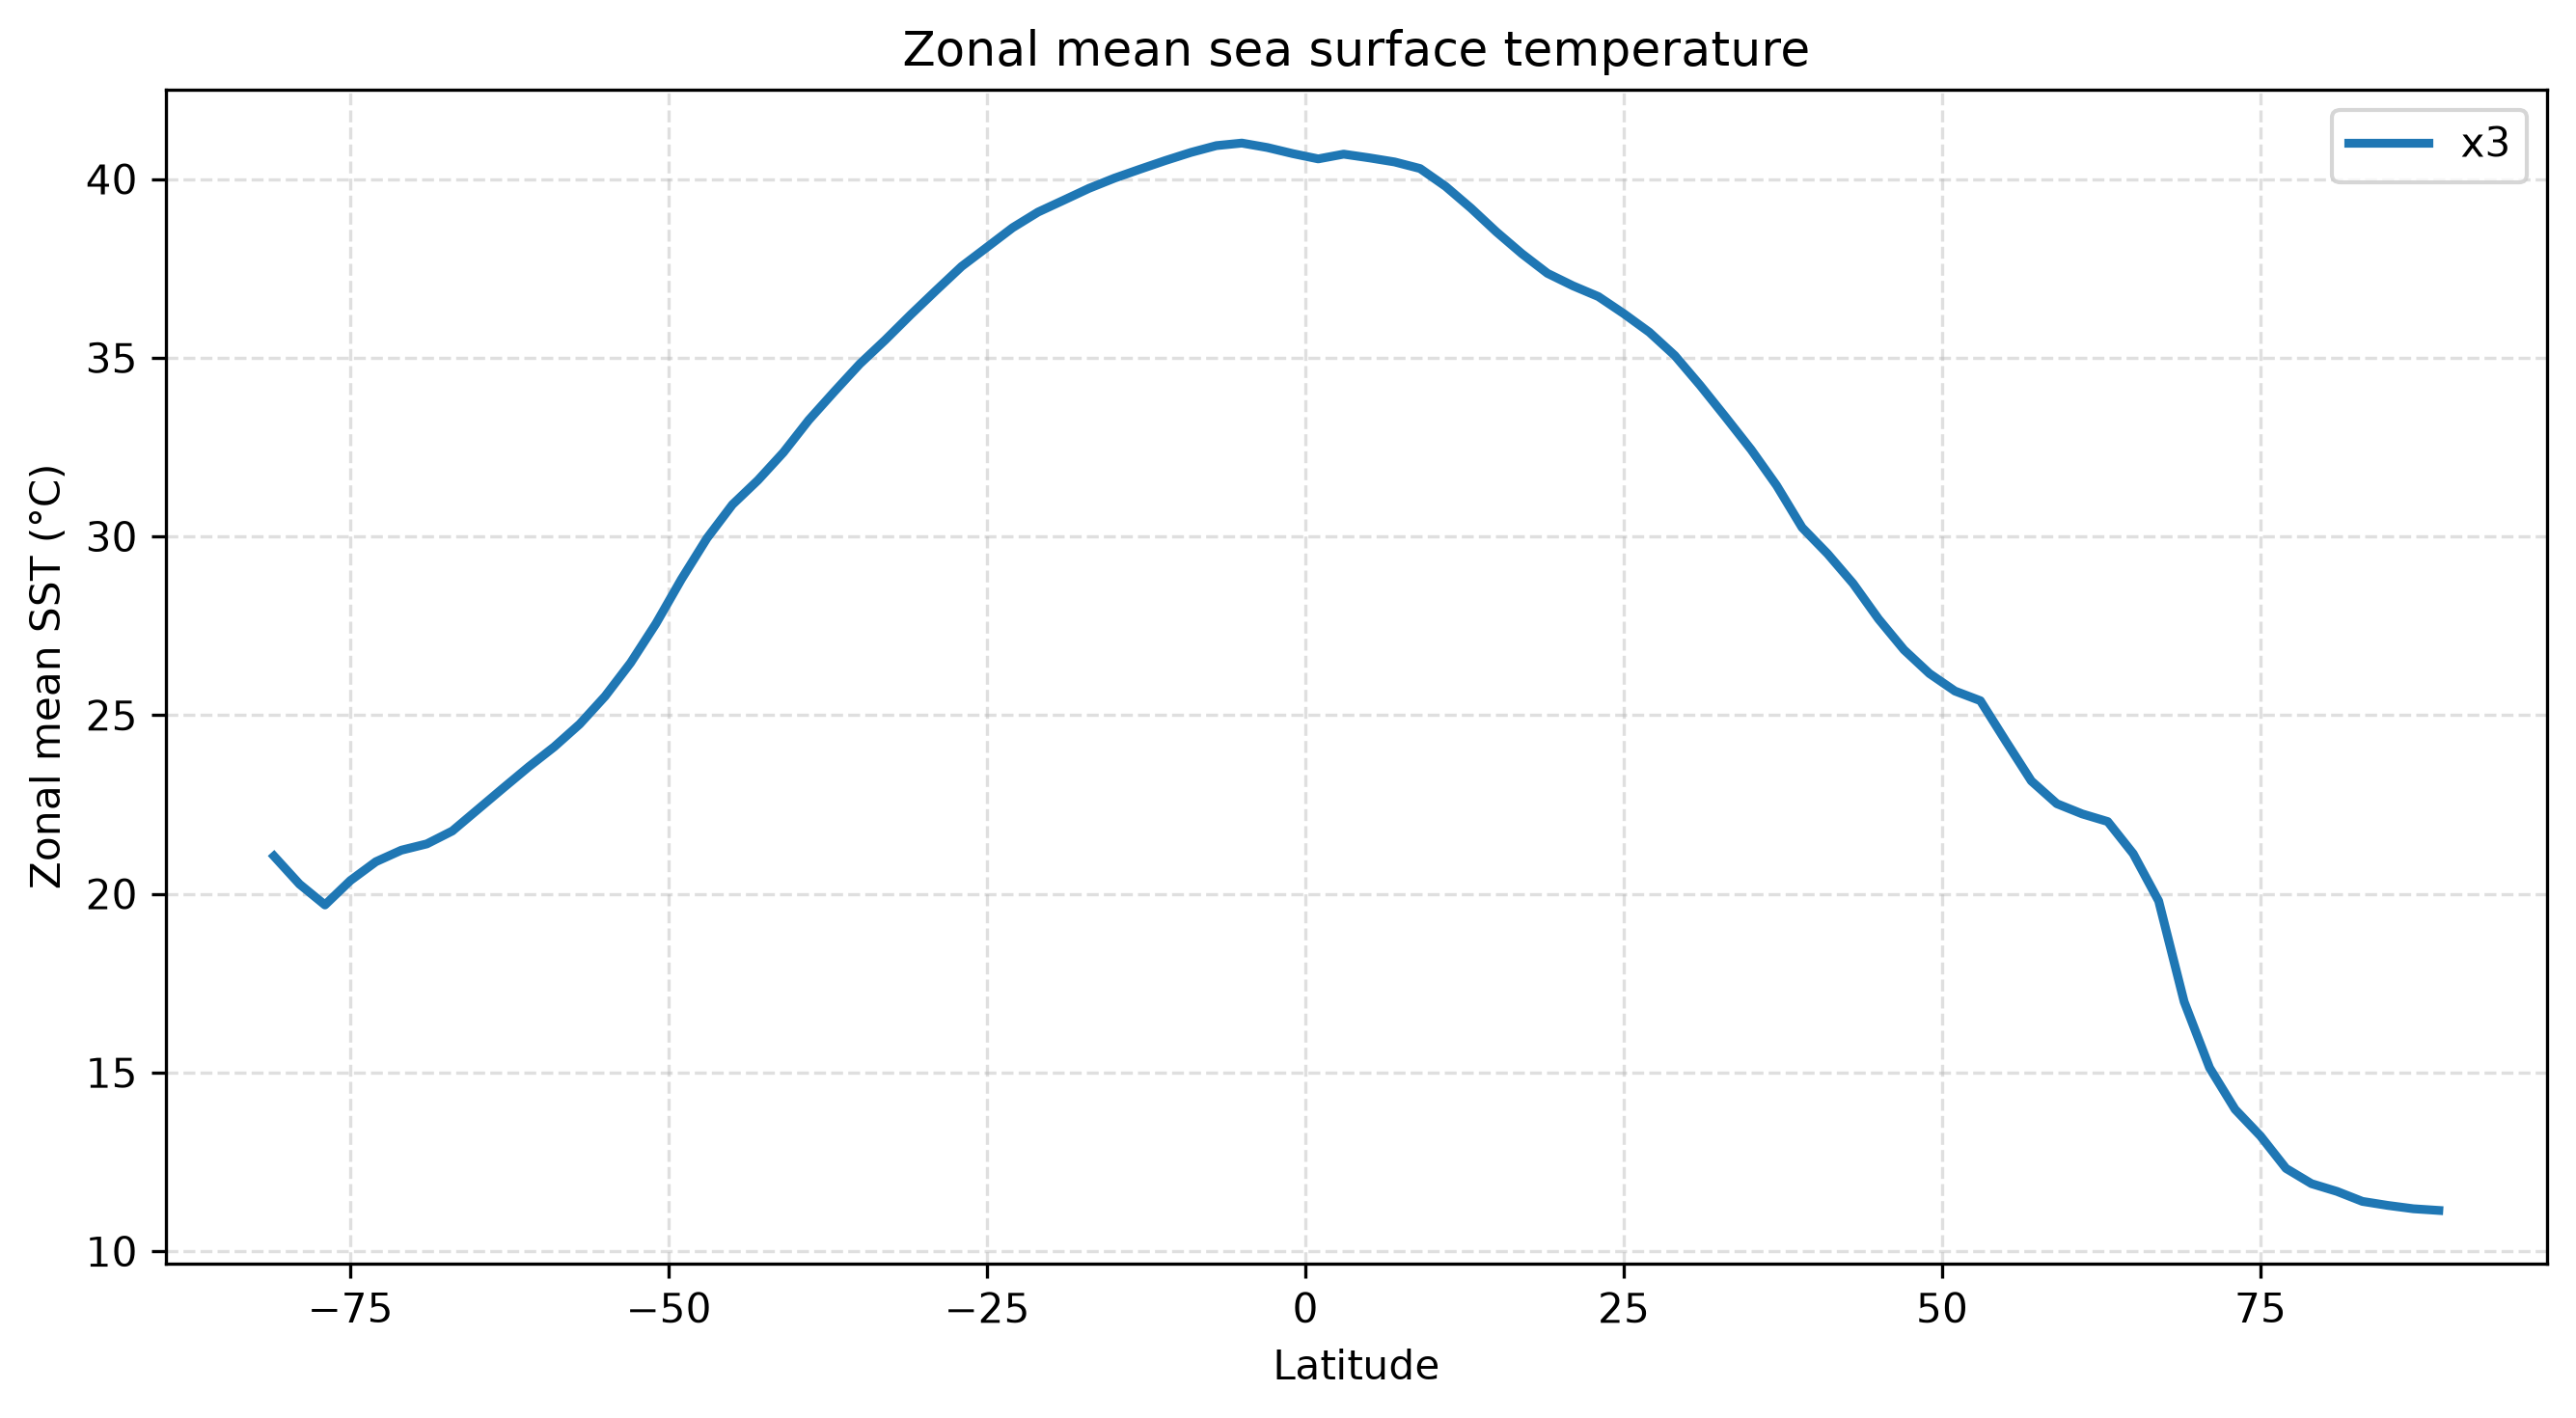

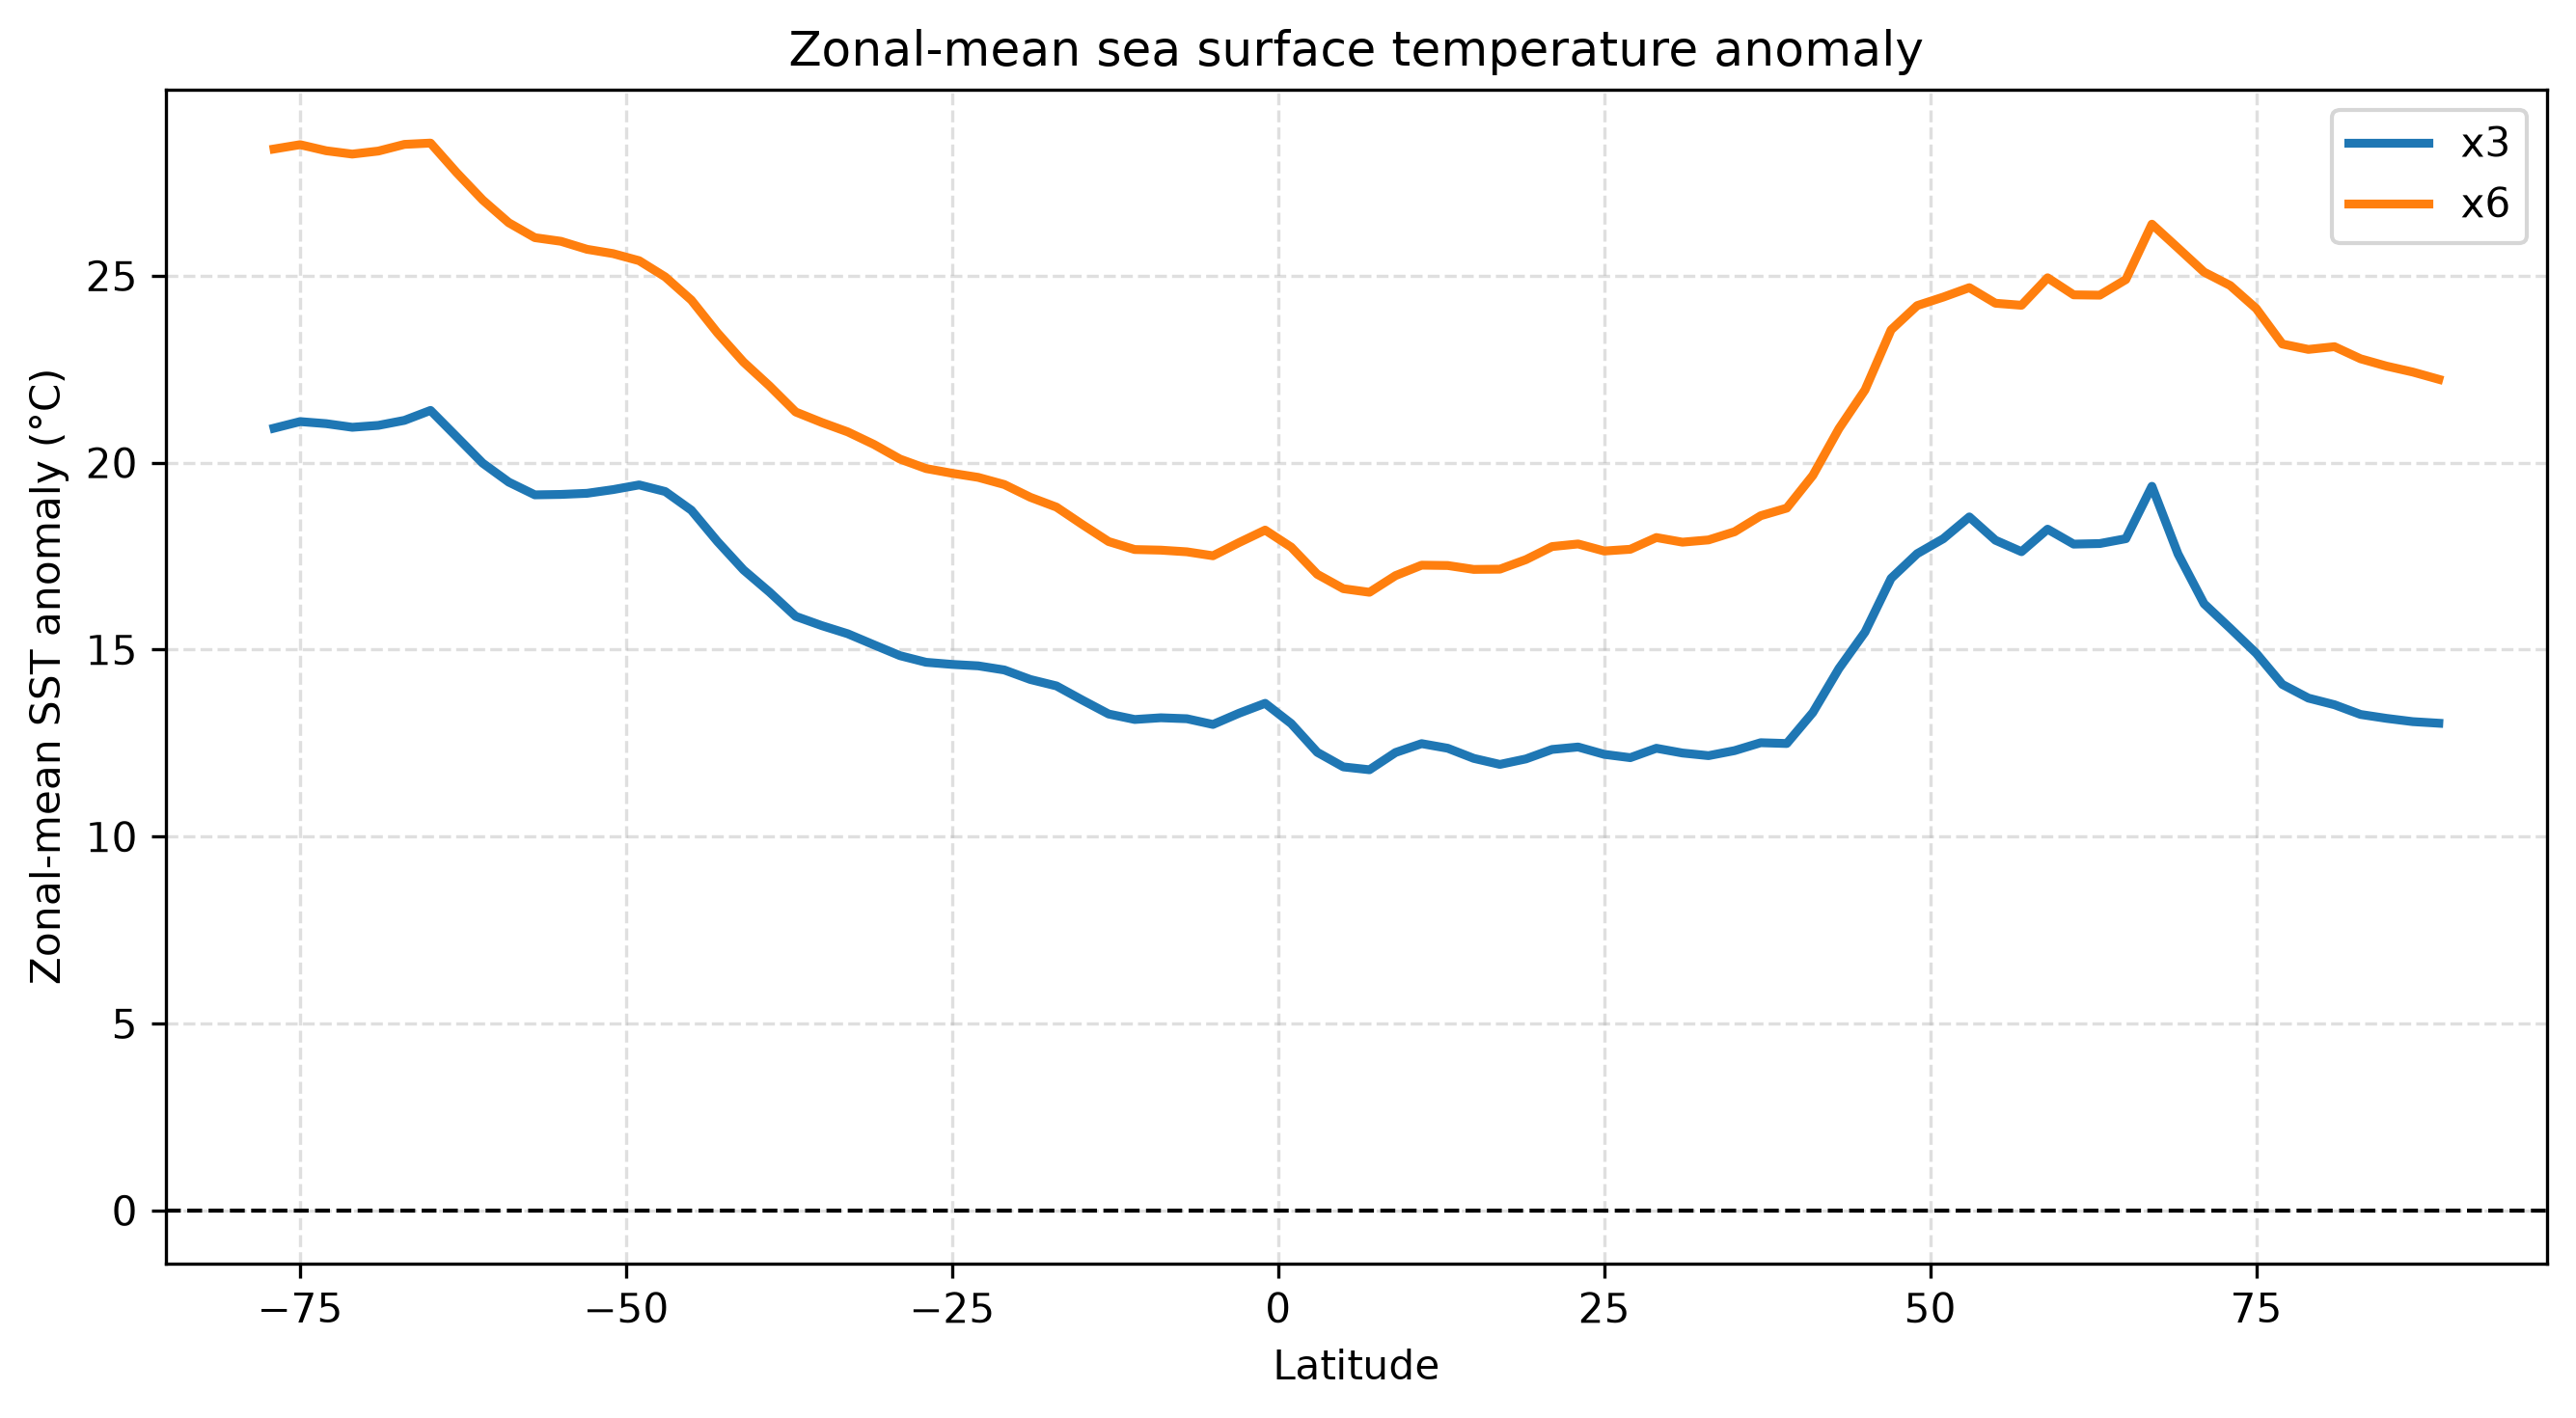

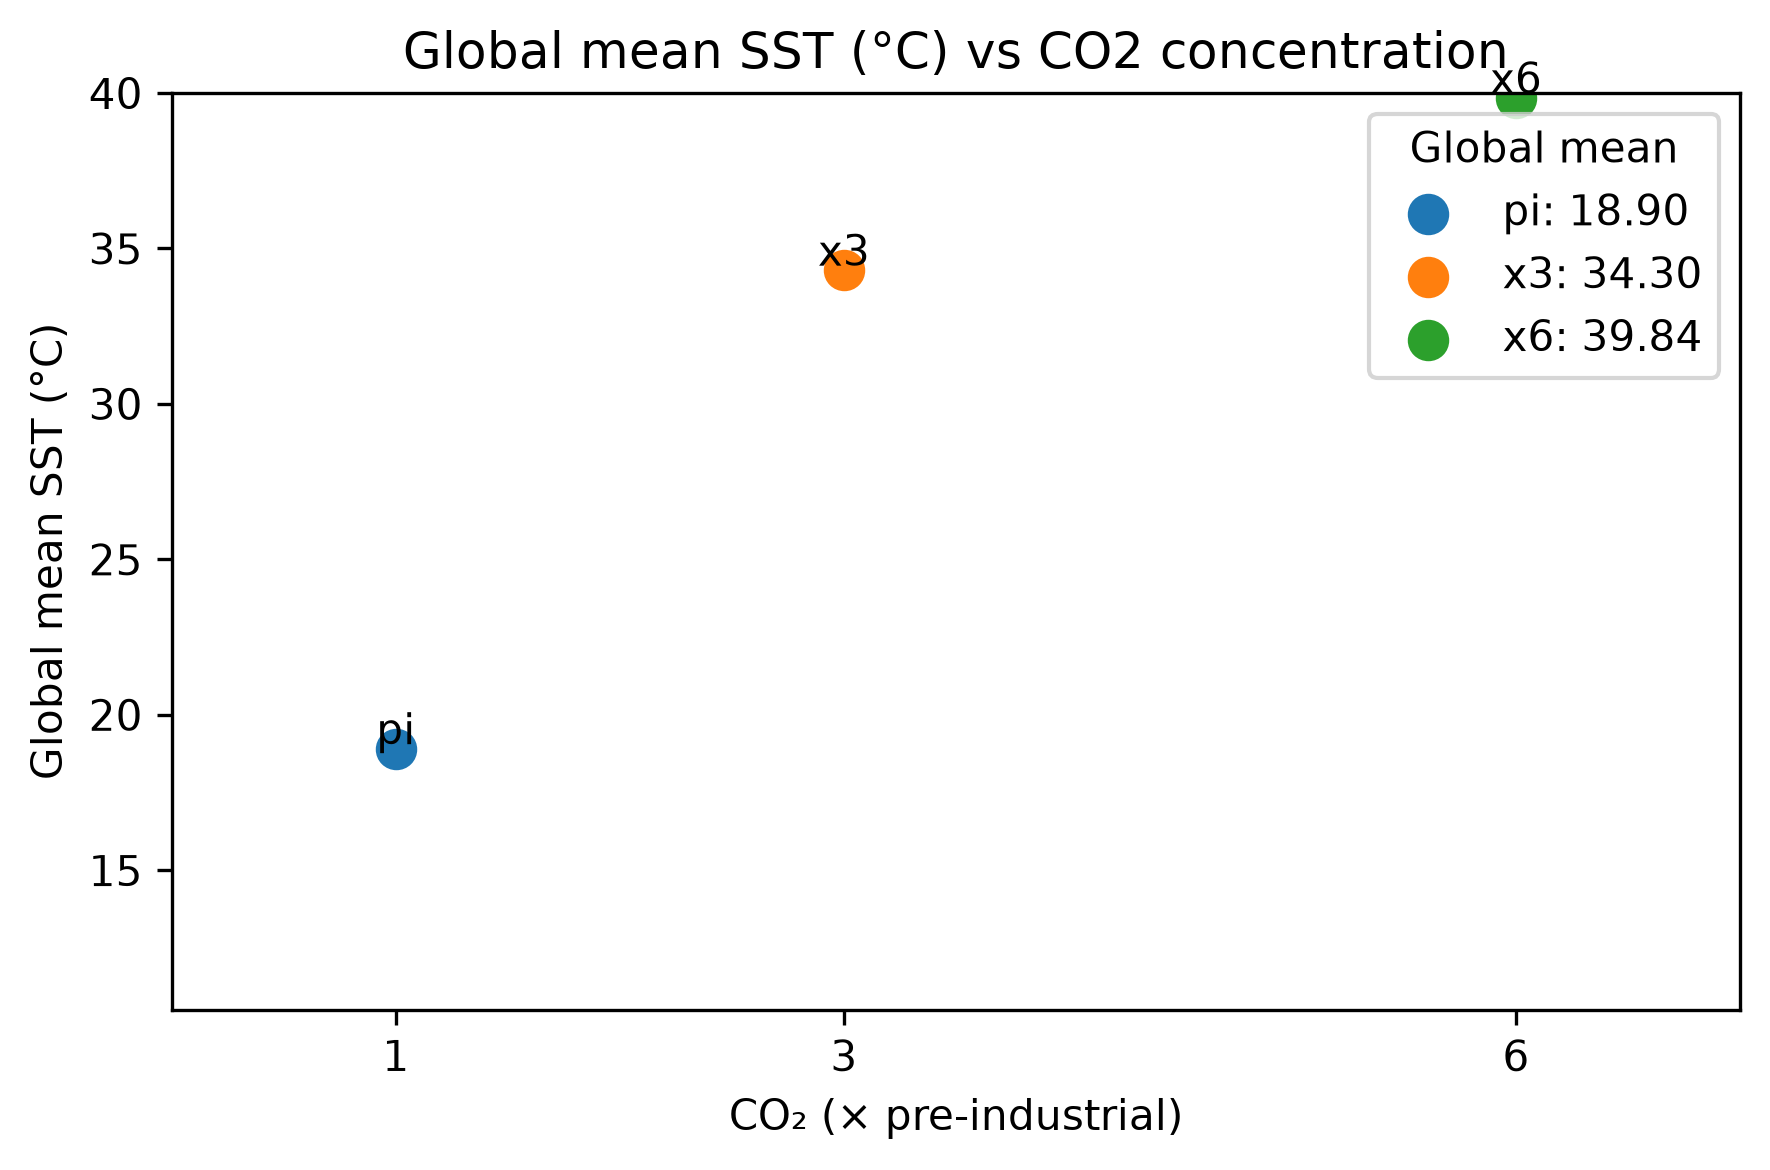

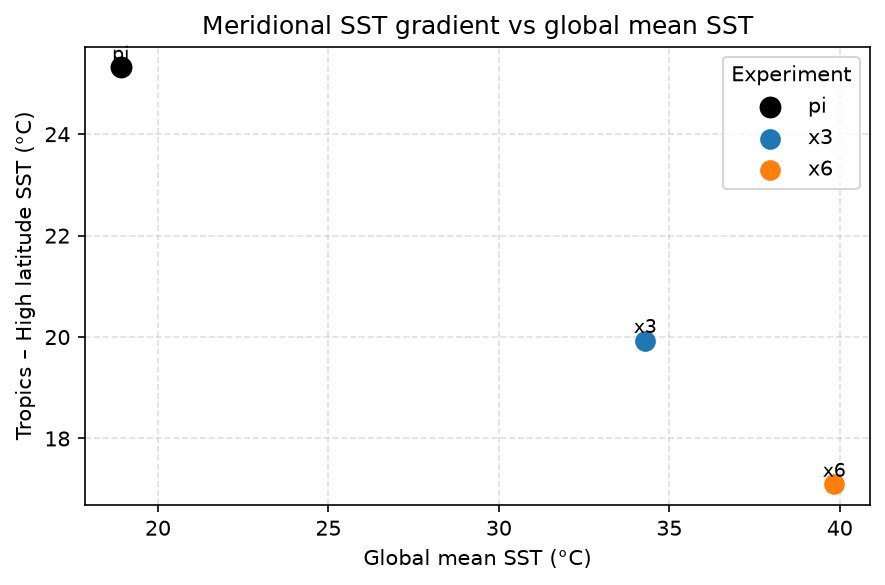

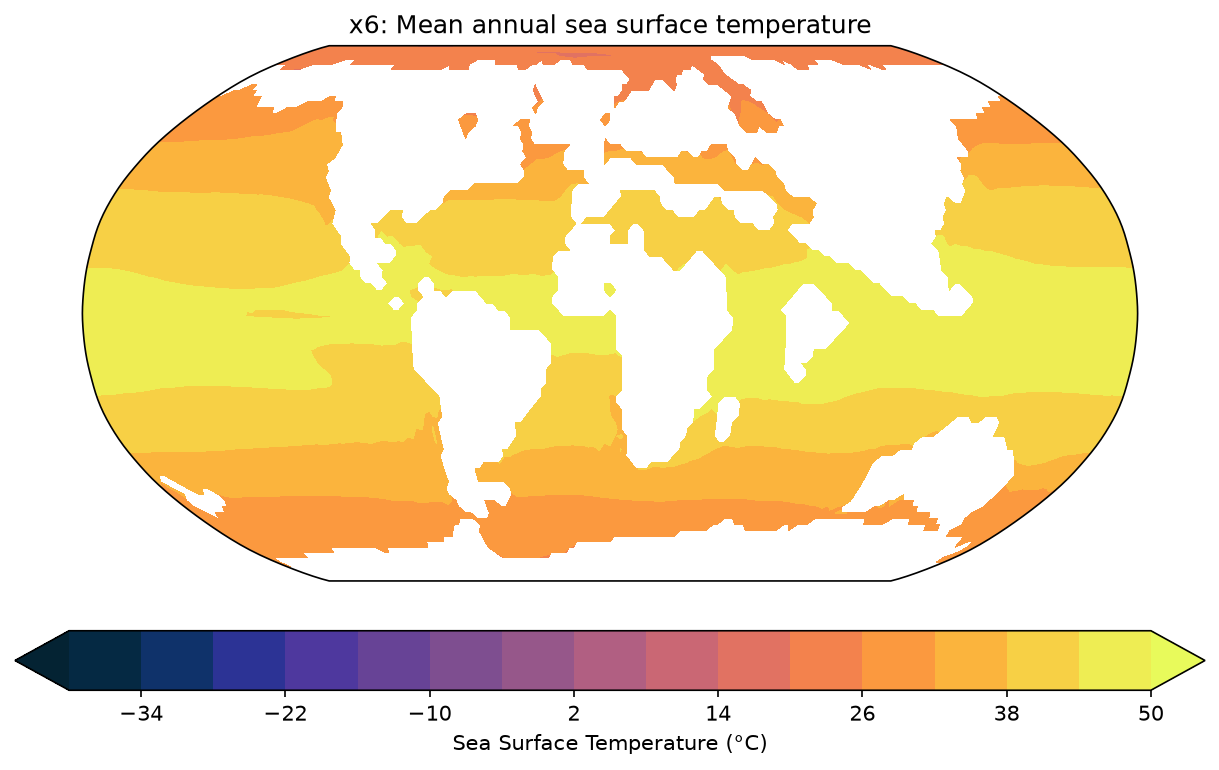

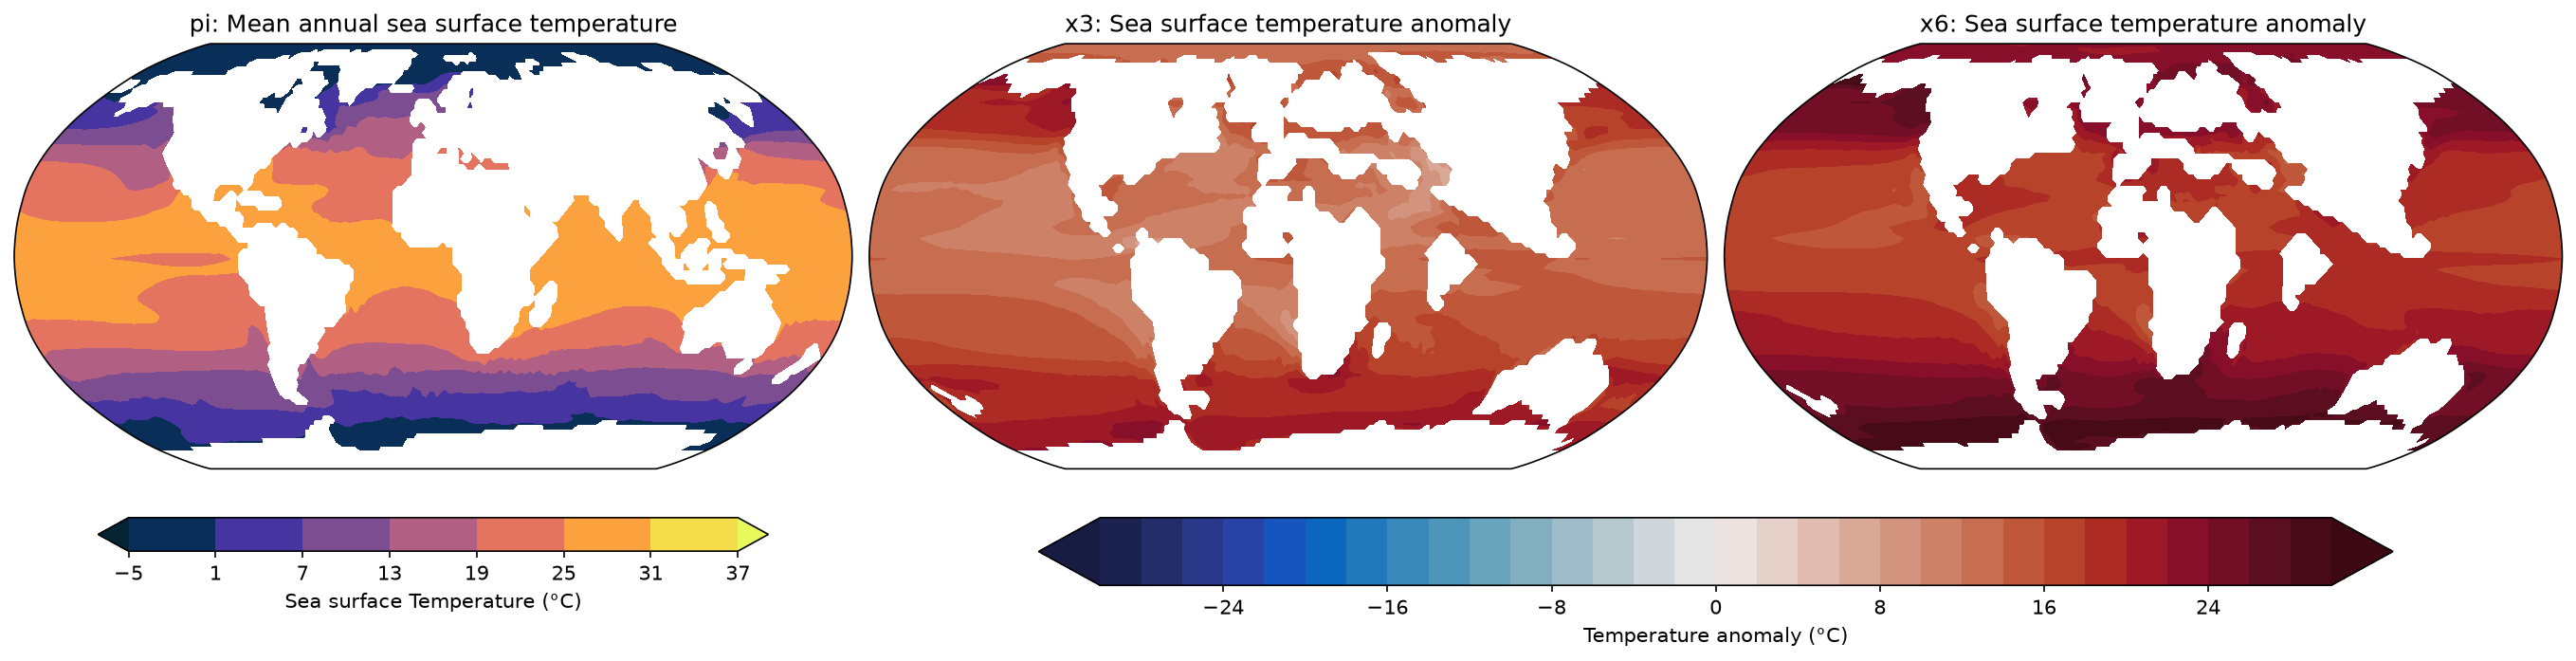

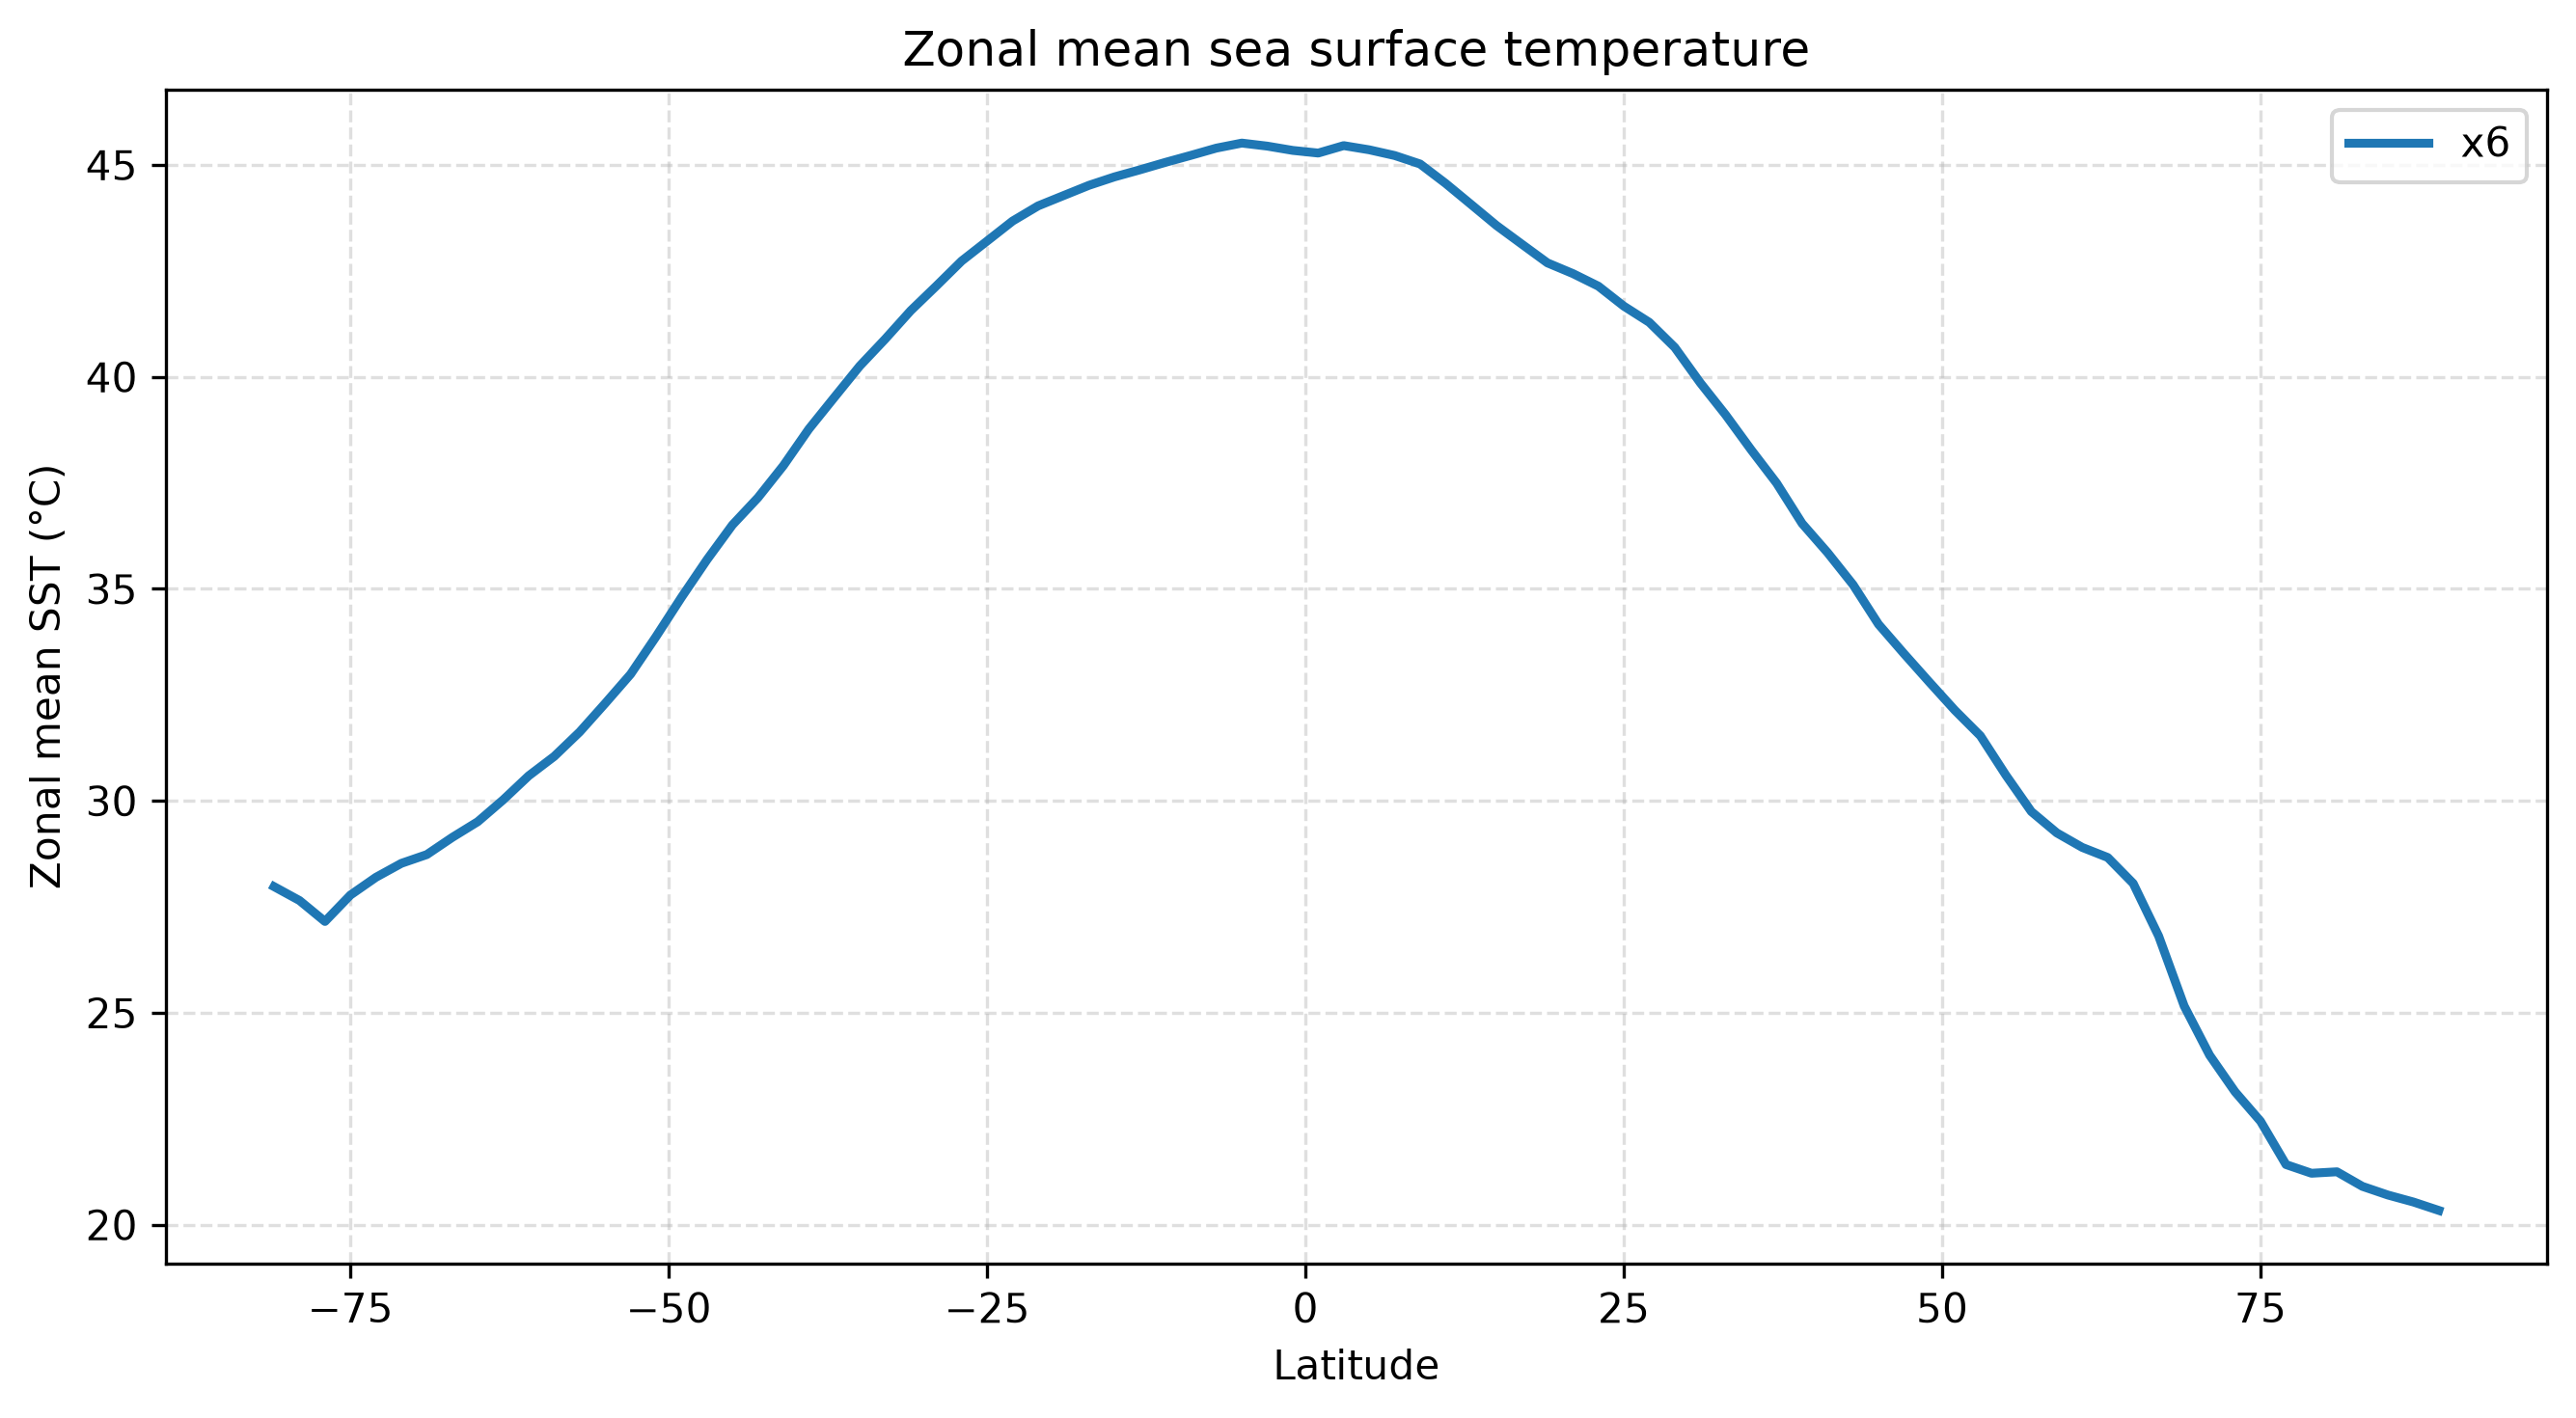

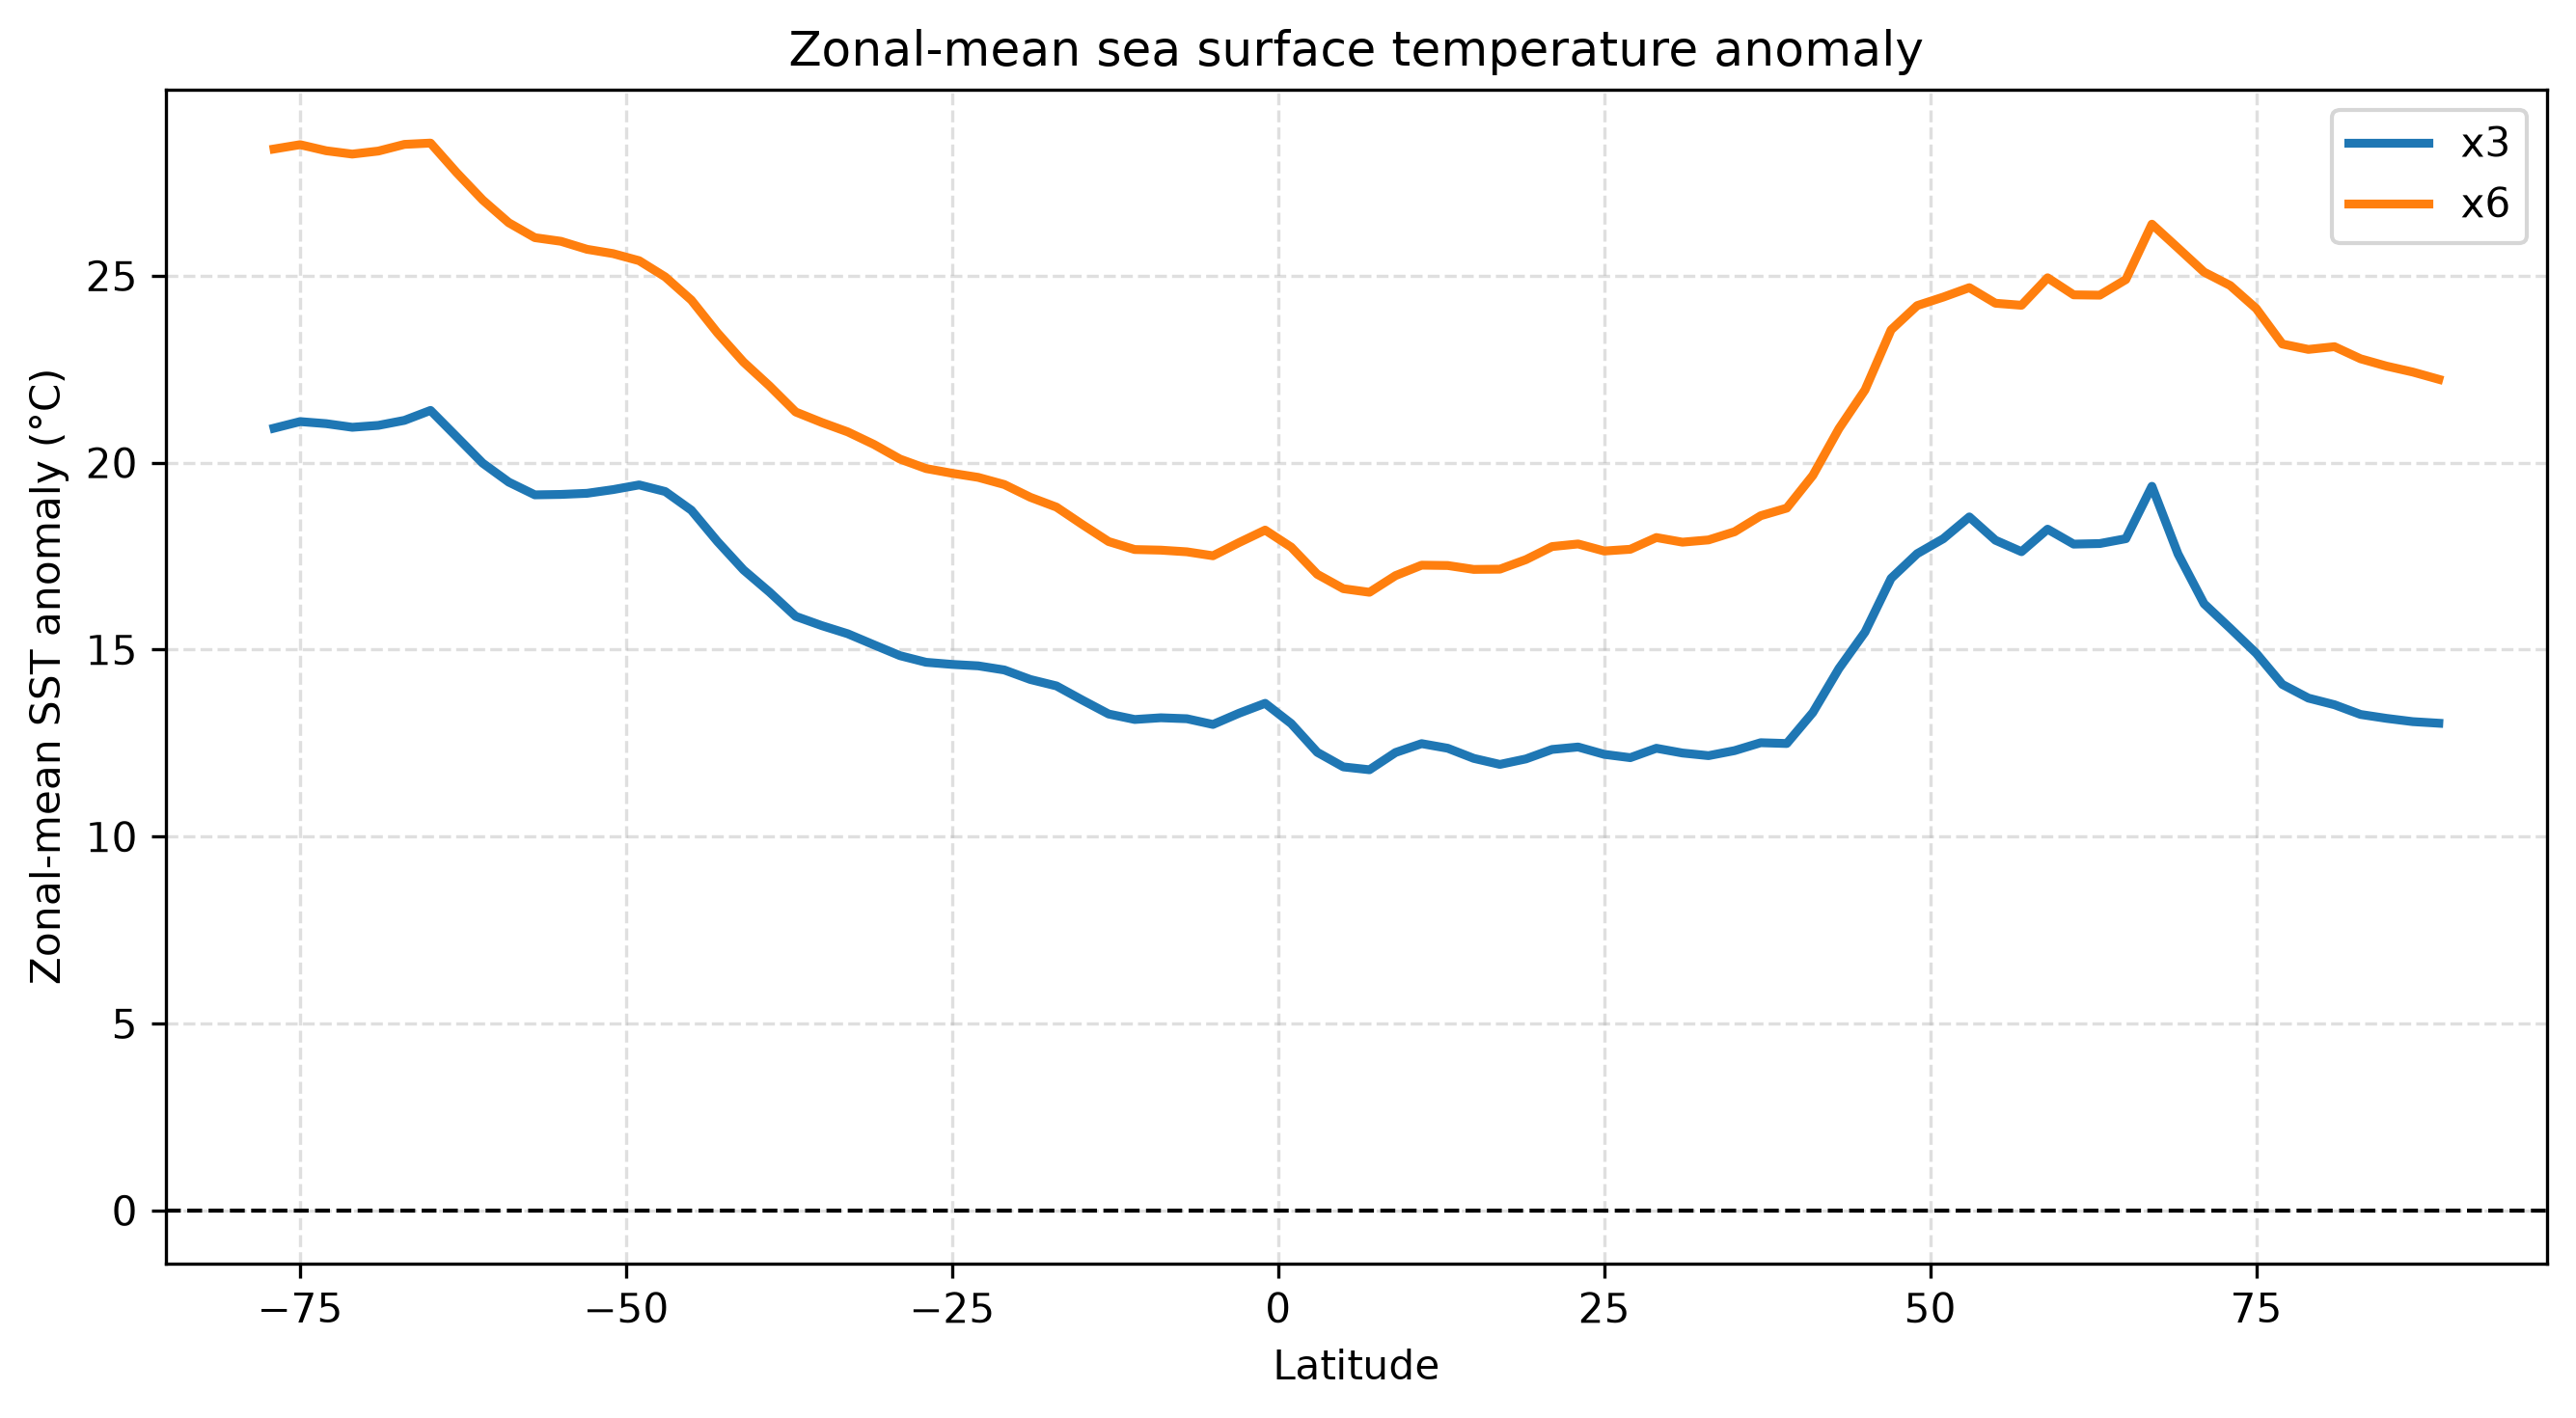

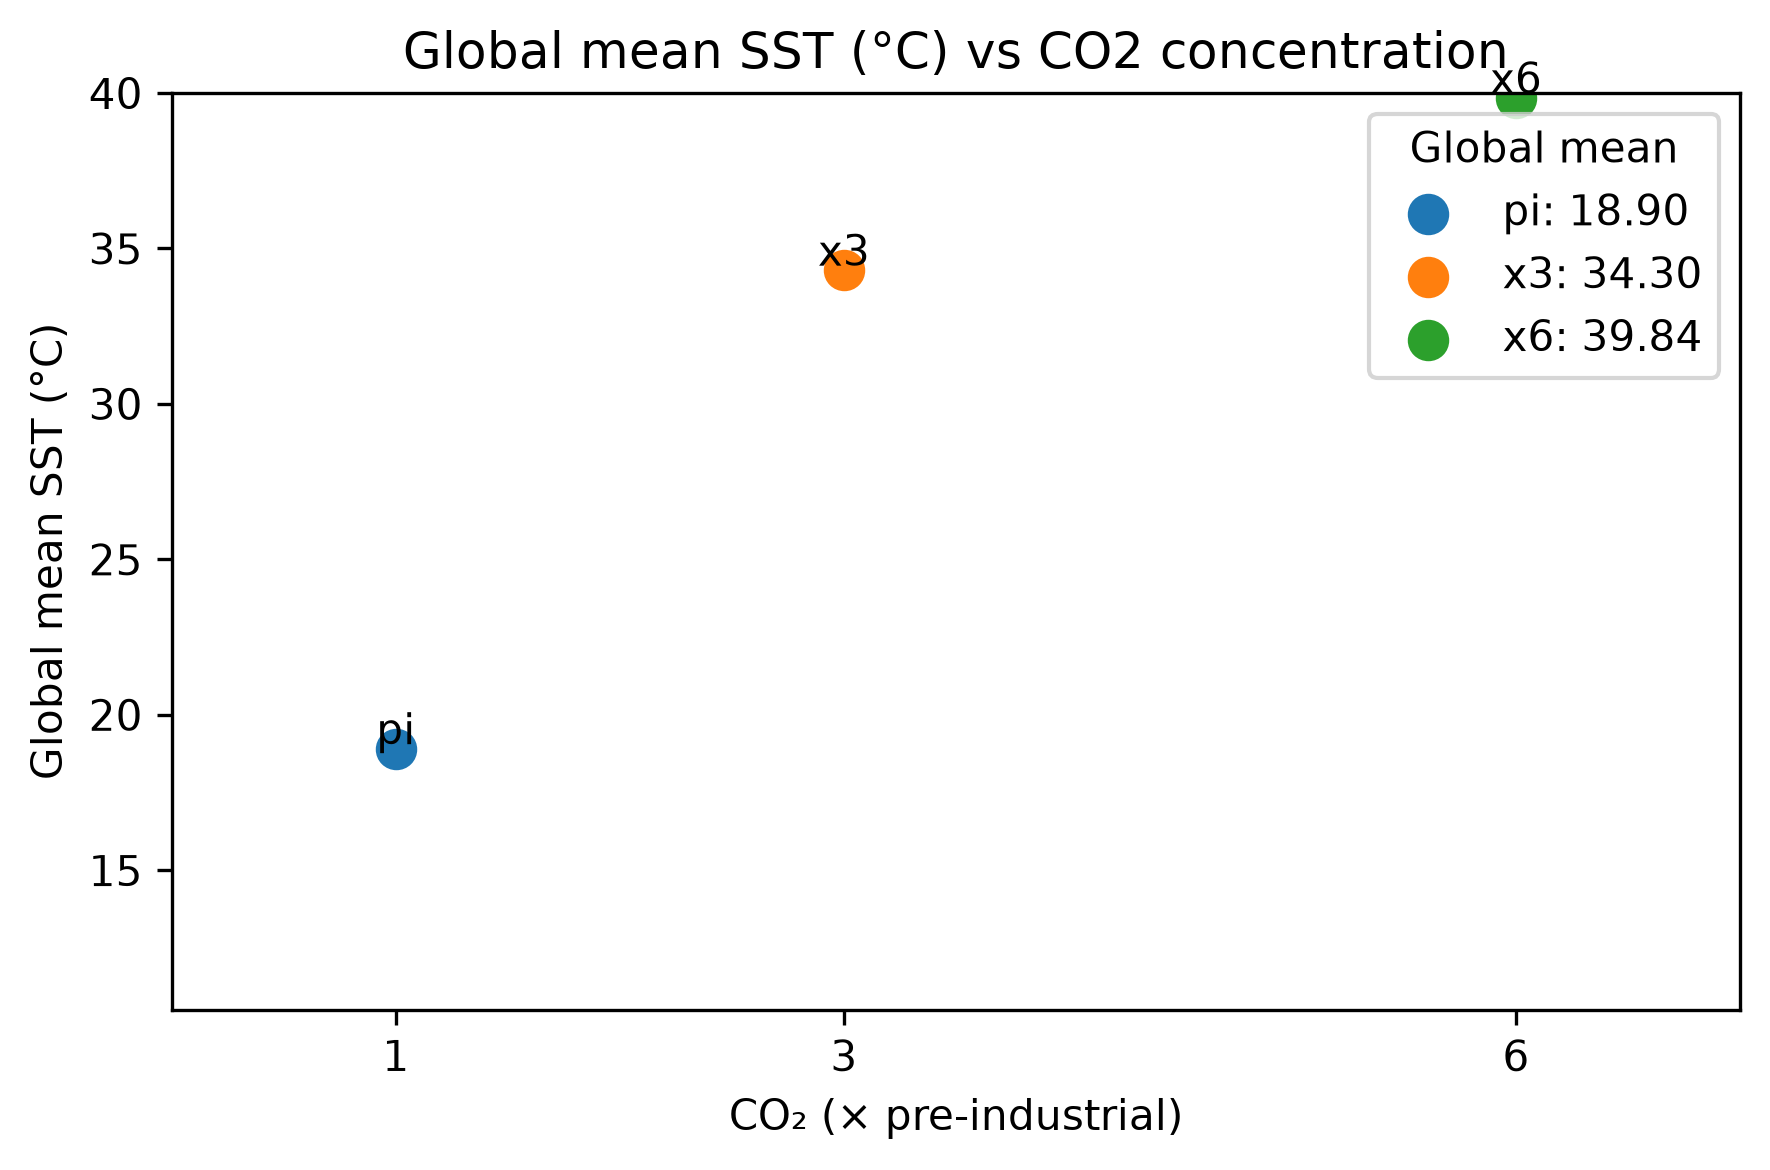

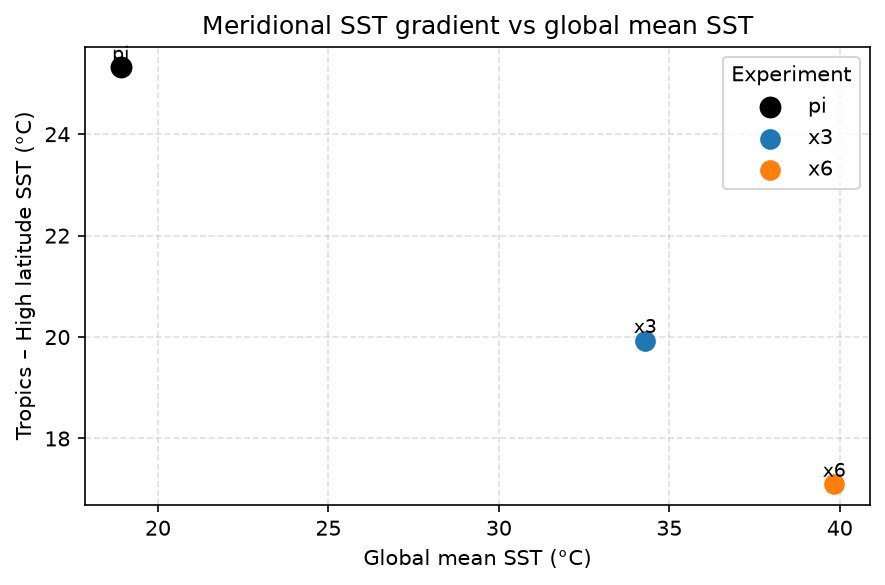

In [ ]:
# ==========================================================
# SST diagnostics
# ==========================================================

diag.tos.run(
    plot=True,
    plot_experiment="x3"
)

diag.tos.run(
    plot=True,
    plot_experiment="x6"
)

## Salinity

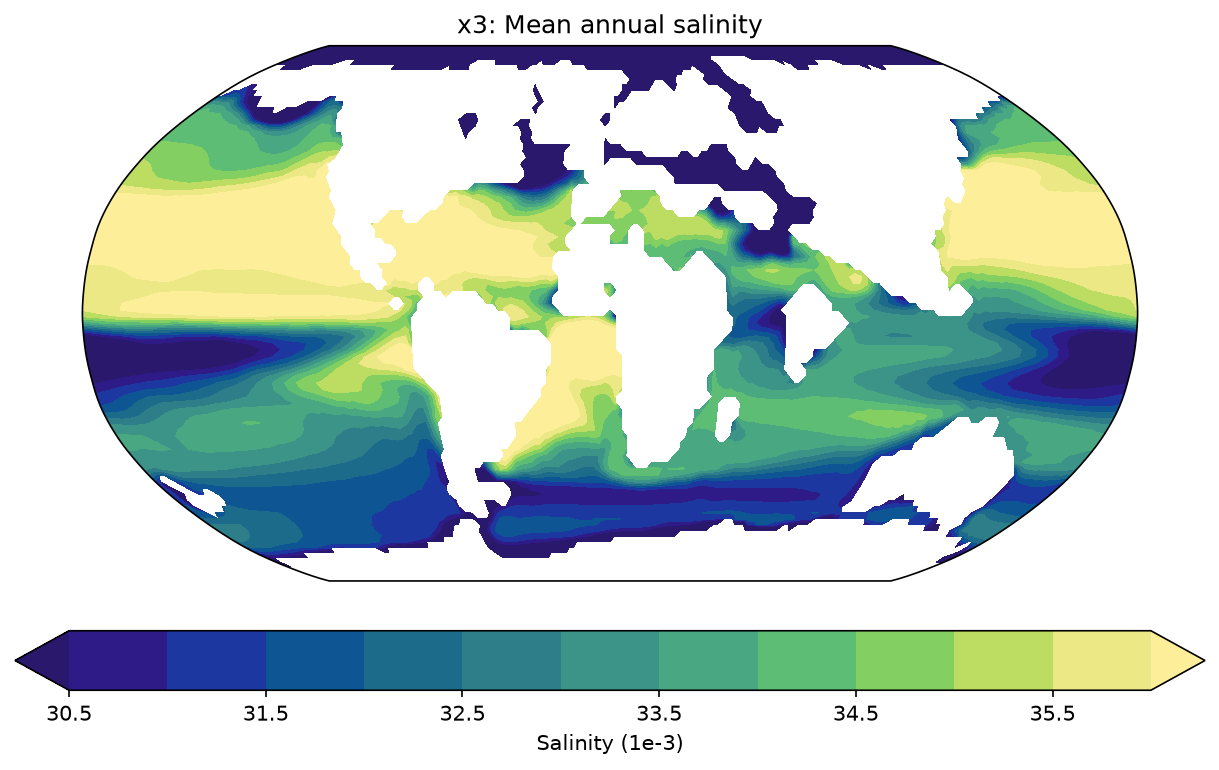

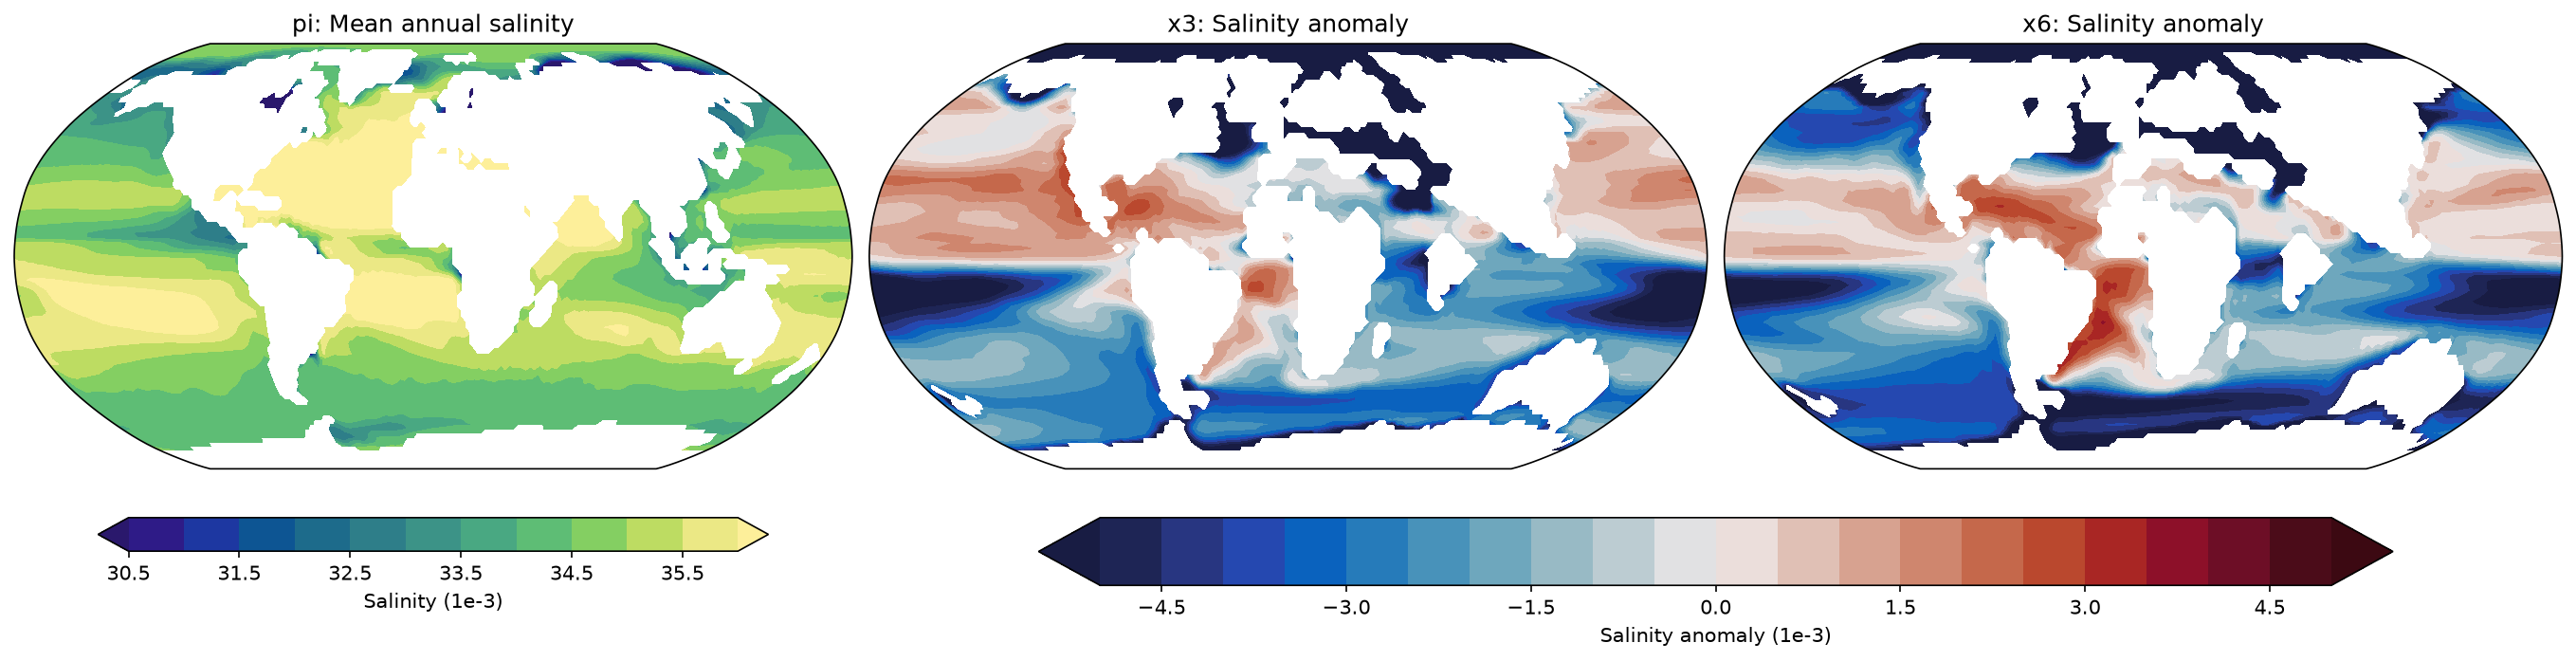

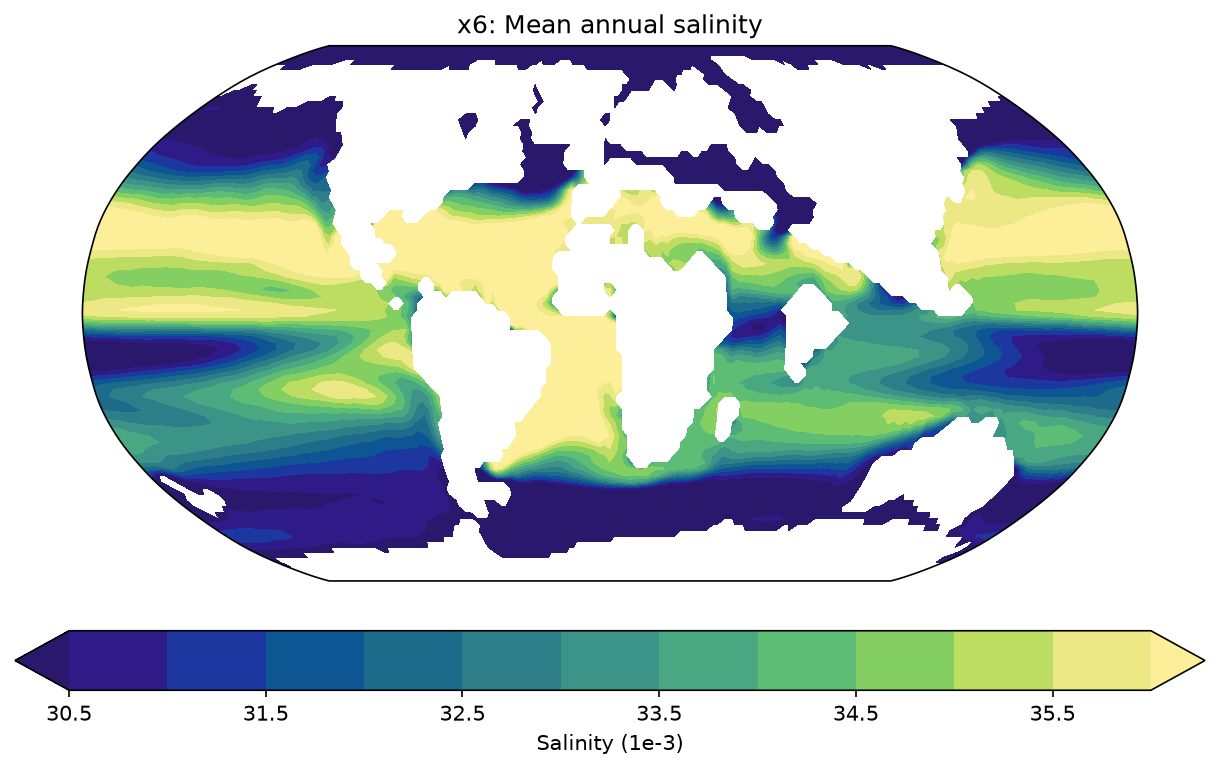

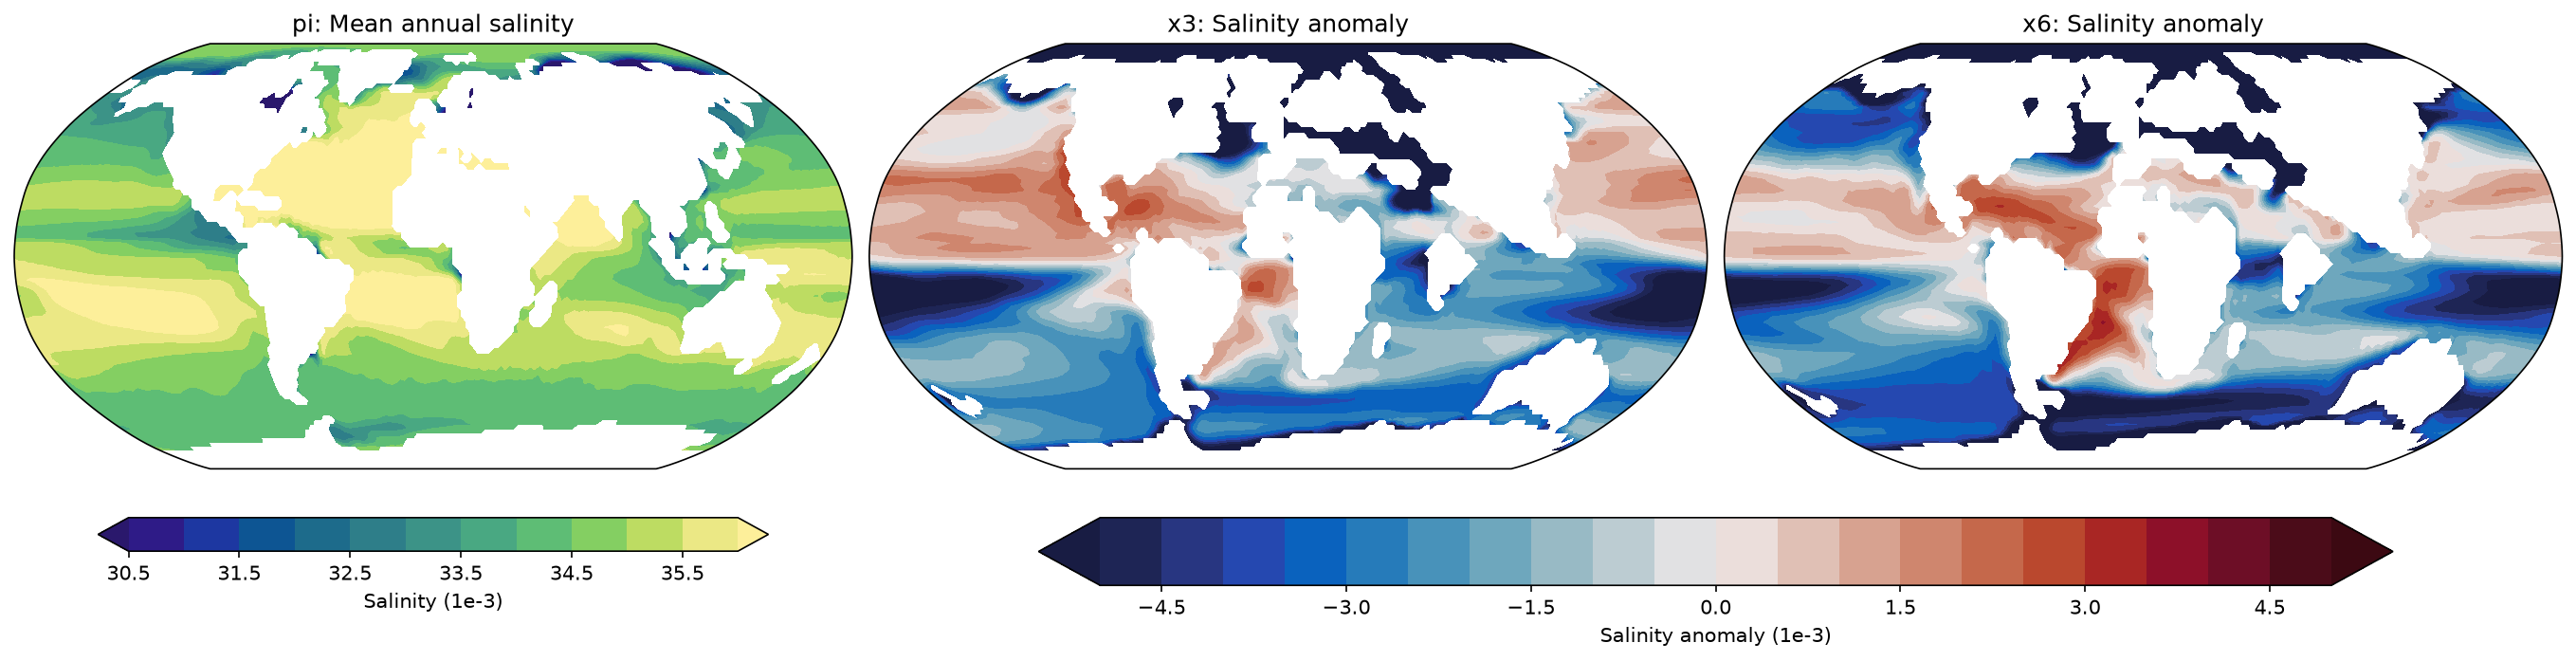

In [ ]:
# ==========================================================
# SOS Diagnostics
# ==========================================================

diag.sos.run(
    plot=True,
    plot_experiment="x3"
)

diag.sos.run(
    plot=True,
    plot_experiment="x6"
)

## DeepMIP comparisons

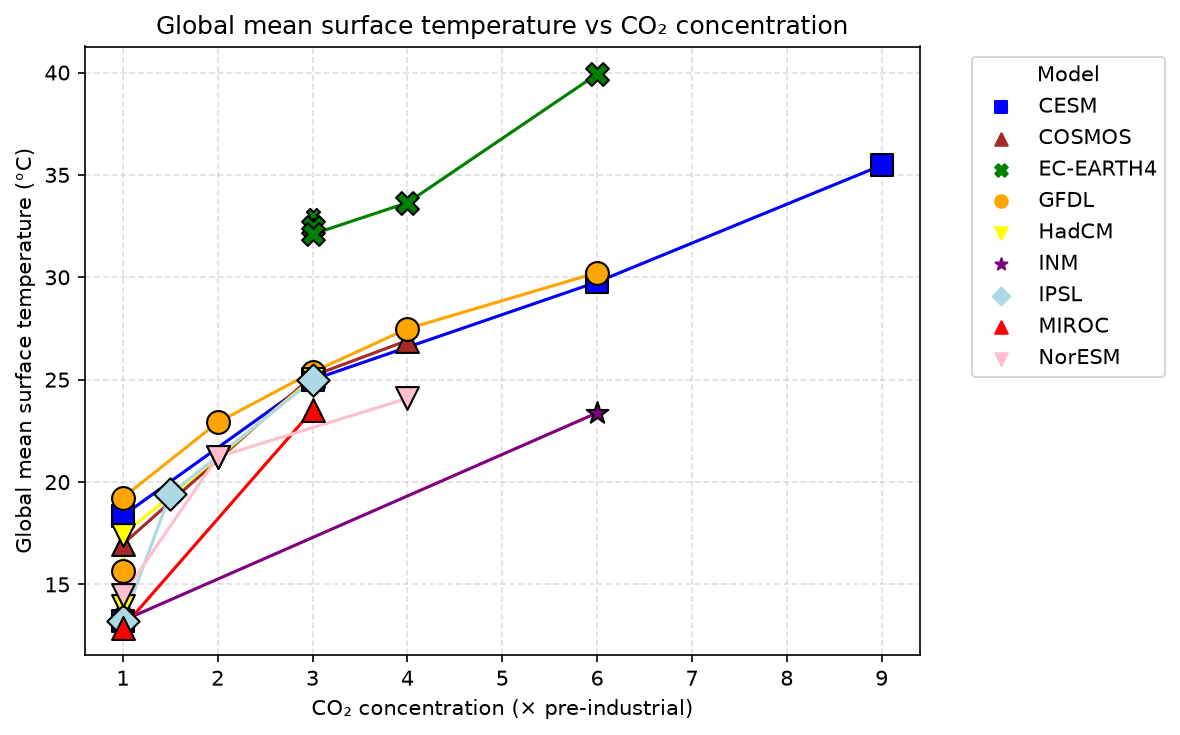

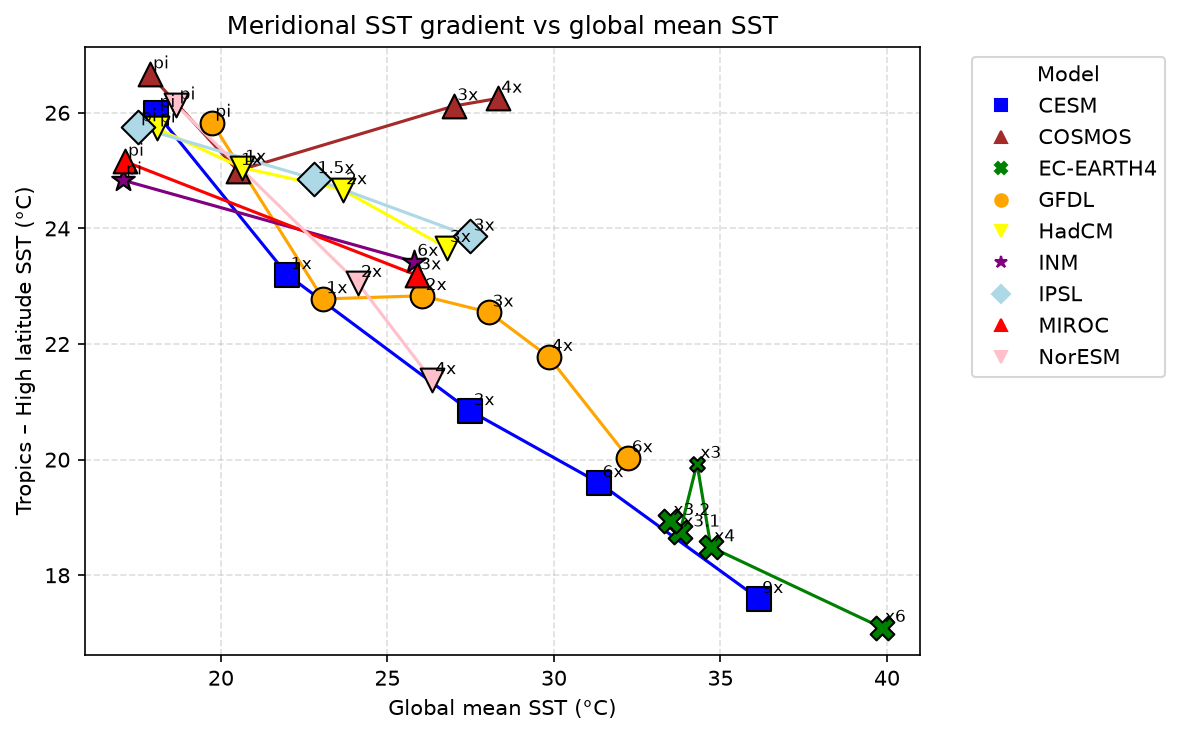

In [4]:
diag.tas.run(plot=False)
diag.tos.run(plot=False)

diag.deepmip.run(
    plot=True,
    own_results=diag.tas.global_mean,
    own_co2_levels=diag.co2_levels,
    own_reference=diag.reference,
    own_sst_results=diag.tos.global_mean,
    own_sst_gradient=diag.tos.dT,
)